# Settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
import scipy.stats as stats
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numdifftools as nd
import pandas as pd
import sys
import astropy.constants as cst
import random
from matplotlib.patches import Patch
import zeus
from chainconsumer import ChainConsumer
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from astropy.io import fits
from tqdm.notebook import tqdm
from IPython.display import display, Markdown, Math

import astropy.units as u
from scipy.integrate import quad

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import lax
from functools import partial

In [2]:
import fisher_matrix_analysis as fma
import basket as ba
import optimisation_functions as opt
import jax_optimizer as opt_jax

/home/cl-a-millard/venvs/jupyter/lib/python3.14/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [3]:
# figure size setting for article

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.sans-serif": "Computer Modern Roman",
    "figure.dpi": 300,
    "figure.figsize": (6.1,4.6),  # Put your journal width here
    "savefig.bbox": "tight"})

# 1. Roman mock data

In [4]:
# define cosmological parameters
H0_fid=73
Mb_fid=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE

fiducial_fLCDM  = [Om0_fLCDM,Mb_fid]

fiducial_kLCDM = [Om0_kLCDM, Ode0_kLCDM, Mb_fid]


fiducial_fwCDM = [Om0_fwCDM, w0_fwCDM, Mb_fid]

fiducial_kwCDM = [Om0_kwCDM, Ode0_kwCDM, w0_kwCDM,Mb_fid]

fiducial_fCPL=[Om0_fCPL,w0_fCPL,wa_fCPL,Mb_fid]
 
# fiducial cosmologie
#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0_fid,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0_fid,Om0=Om0_fLCDM,Ode0=Ode0_fLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0_fid,Om0=Om0_fLCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0_fid,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL=ac.Flatw0waCDM(H0=H0_fid,Om0=Om0_fCPL,w0=w0_fCPL,wa=wa_fCPL)

In [5]:
# Roman data

roman = pd.read_csv('roman_data/mock_roman.csv', sep=';')
z_roman = roman.z.values
dist_roman = roman.Nstar.values
#dist_roman = np.full_like(np.array(z_roman),200) # fake flat distribution
cov = fits.getdata("roman_data/roman_cov.fits")

# last row is the redshifts -> no it is the first one actually
Cov_roman = cov[1:, :]
Cov_roman = np.asarray(Cov_roman).astype(np.float64)
II = np.eye(Cov_roman.shape[0])
Cov_inv_roman = np.linalg.solve(Cov_roman, II)
sigma_roman = np.sqrt(np.diag(Cov_roman))

# define bin edges
edges_mid = 0.5 * (z_roman[1:] + z_roman[:-1])
# first and last edges
first_edge = z_roman[0] - (edges_mid[0] - z_roman[0])
last_edge  = z_roman[-1] + (z_roman[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

In [6]:
upper_bound = np.load('SNIa_count.npz')
NIa_tot = upper_bound['NIa_tot']

In [7]:
z_roman

array([0.075, 0.125, 0.175, 0.225, 0.275, 0.325, 0.375, 0.425, 0.475,
       0.525, 0.575, 0.625, 0.675, 0.725, 0.775, 0.825, 0.875, 0.925,
       0.975, 1.025, 1.075, 1.125, 1.175, 1.225, 1.275, 1.325, 1.375,
       1.425, 1.475, 1.525, 1.575, 1.625, 1.675, 1.725, 1.775, 1.825,
       1.875, 1.925, 1.975, 2.025, 2.075, 2.125, 2.175, 2.225, 2.275,
       2.325, 2.375, 2.425, 2.475, 2.525, 2.575, 2.625, 2.675, 2.725,
       2.775, 2.825, 2.875, 2.925, 2.975])

In [8]:
lsst_SNIa = np.zeros_like(z_roman)
lsst_SNIa[0] = 801 # 800 SNIa at z<0.09

# bon clairement le  3600 est overestimated ou déjà enlevée
# for i in range(1,9):
#     lsst_SNIa[i] = 350 # 3600-800 SNIa at z>0.5 equally divided between the 8 bins

dist_roman_without_lsst = np.copy(dist_roman) - lsst_SNIa
dist_roman_without_lsst

array([ 10.,  24.,  53.,  79., 106., 146., 189., 233., 266., 313., 375.,
       424., 471., 539., 563., 608., 629., 660., 700., 670., 654., 659.,
       650., 612., 556., 516., 504., 436., 409., 374., 331., 289., 270.,
       223., 175., 161., 151., 132., 110.,  90.,  78.,  82.,  69.,  51.,
        59.,  45.,  44.,  32.,  22.,  20.,  11.,  10.,  11.,   9.,   8.,
         4.,   3.,   3.,   4.])

In [9]:
fma.is_positive_definite(Cov_roman)

True

In [10]:
off_diagonal = Cov_roman-np.diag(np.diag(Cov_roman))
Cov_roman_sys = off_diagonal.copy()

n = off_diagonal.shape[0]

for i in range(n):
    # only diagonal elements
    # (since matrix is square, i == j)
    
    # define neighborhood
    i_min = max(i - 1, 0)
    i_max = min(i + 2, n)

    submatrix = off_diagonal[i_min:i_max, i_min:i_max]

    # build global indices
    rows, cols = np.indices(submatrix.shape)
    global_rows = rows + i_min
    global_cols = cols + i_min

    # keep only OFF-diagonal elements (global condition)
    mask = global_rows != global_cols
    values = submatrix[mask]

    Cov_roman_sys[i, i] = values.mean()

Cov_roman_stat = Cov_roman-Cov_roman_sys

In [11]:
fma.is_positive_definite(Cov_roman_stat), fma.is_positive_definite(Cov_roman)

(True, True)

In [12]:
opt.nearest_psd(Cov_roman_stat)

array([[4.37855228e-05, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 3.53195528e-04, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.31440811e-04, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        2.38007761e-02, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 2.74056545e-02, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 2.33387835e-02]], shape=(59, 59))

In [13]:
# Mock (not noisy) data
mock_roman = np.load('roman_data/NGR_fCPL.npz')
mb_roman = mock_roman['mb']

In [14]:
# roman cost
tt = ba.T_ngrt(z_roman)
tt.shape

(59,)

In [15]:
dist_roman, z_edges

(array([811,  24,  53,  79, 106, 146, 189, 233, 266, 313, 375, 424, 471,
        539, 563, 608, 629, 660, 700, 670, 654, 659, 650, 612, 556, 516,
        504, 436, 409, 374, 331, 289, 270, 223, 175, 161, 151, 132, 110,
         90,  78,  82,  69,  51,  59,  45,  44,  32,  22,  20,  11,  10,
         11,   9,   8,   4,   3,   3,   4]),
 array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
        0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 ,
        1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65,
        1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 ,
        2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 , 2.75,
        2.8 , 2.85, 2.9 , 2.95, 3.  ]))

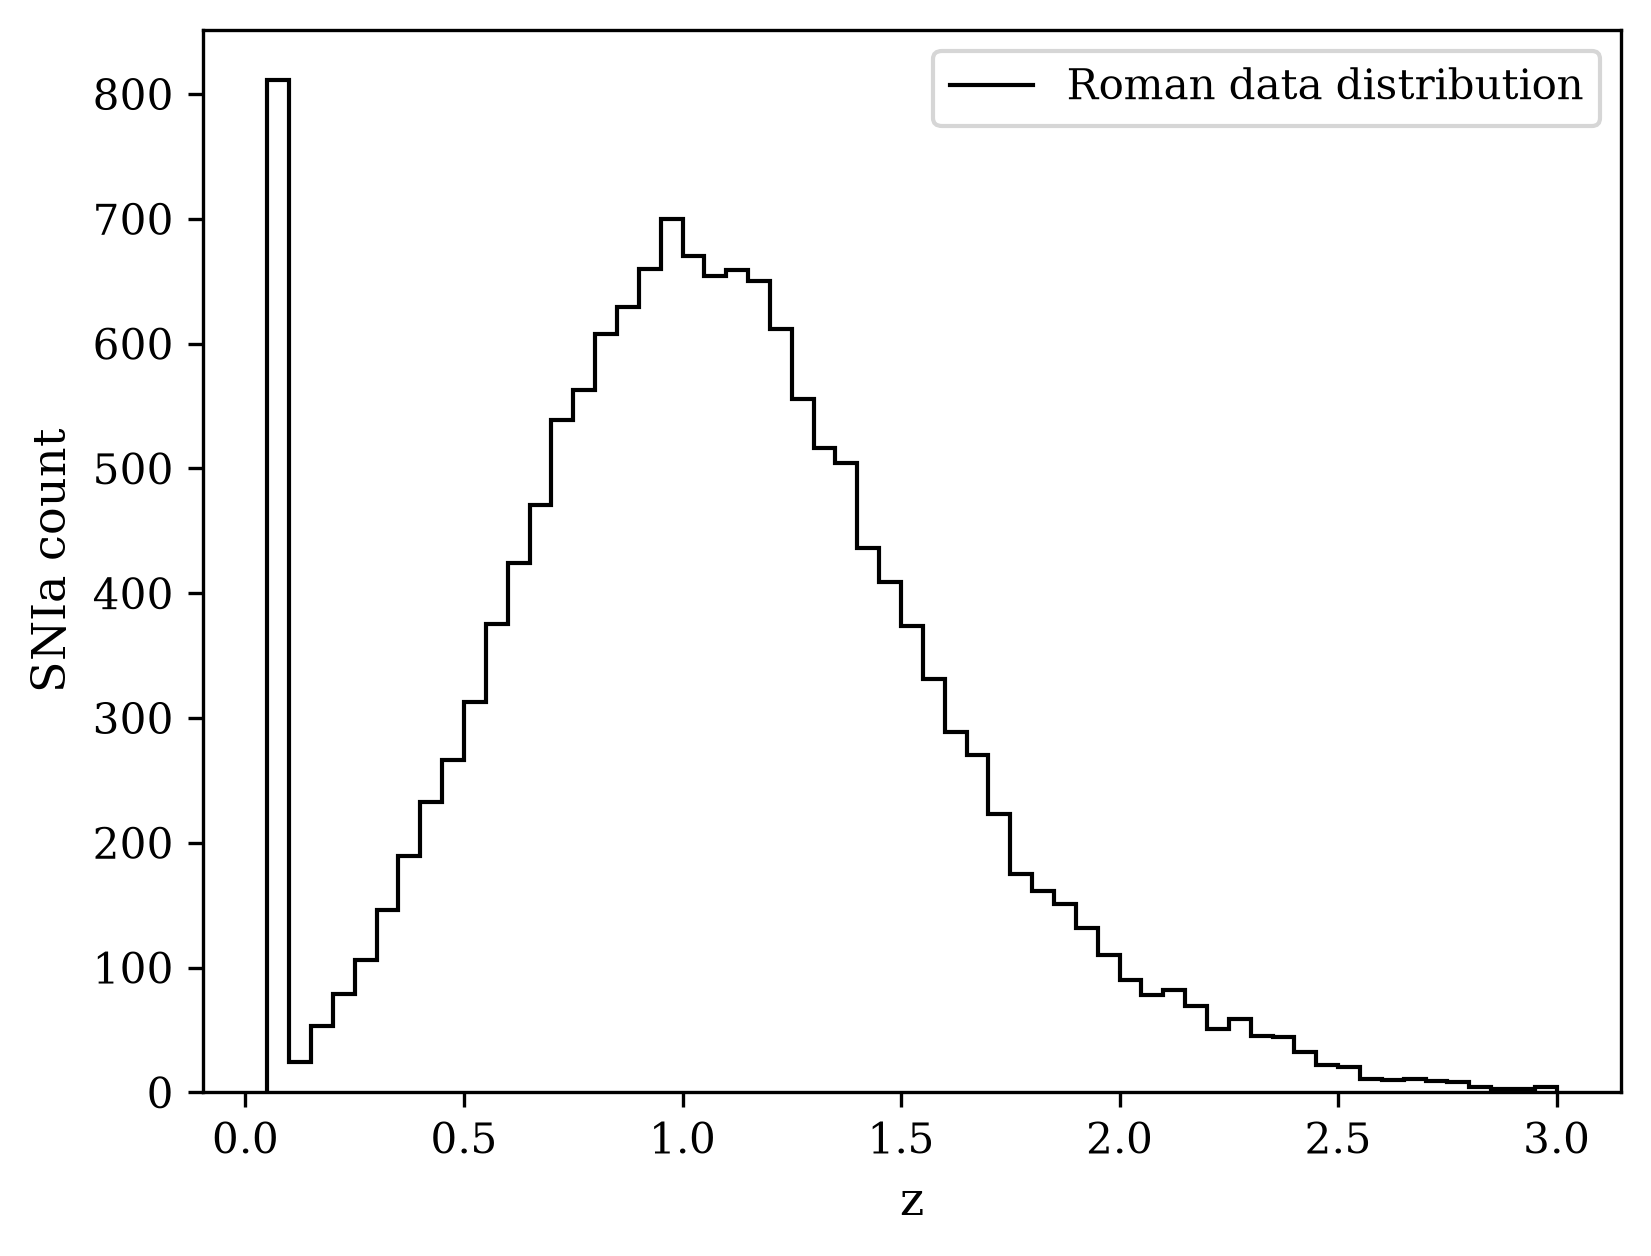

In [16]:
# Estimate bin edges

# plot
plt.stairs(dist_roman, z_edges, label="Roman data distribution", color="black")
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
##plt.savefig("figures/roman_data_distribution")
plt.show()

In [17]:
dist_roman-lsst_SNIa

array([ 10.,  24.,  53.,  79., 106., 146., 189., 233., 266., 313., 375.,
       424., 471., 539., 563., 608., 629., 660., 700., 670., 654., 659.,
       650., 612., 556., 516., 504., 436., 409., 374., 331., 289., 270.,
       223., 175., 161., 151., 132., 110.,  90.,  78.,  82.,  69.,  51.,
        59.,  45.,  44.,  32.,  22.,  20.,  11.,  10.,  11.,   9.,   8.,
         4.,   3.,   3.,   4.])

In [18]:
bin_size = z_roman[1] - z_roman[0]
obs_time_roman = (dist_roman * tt).sum()

display(Markdown(rf"""
<div style="border:1px solid #999; padding:10px; border-radius:6px">

**Roman Survey Data Overview**

- Total number of Type Ia supernovae: {dist_roman.sum():,.0f}  
- Redshift bin size: $\Delta z = {bin_size:.3f}$  
- Total number of bins: {len(z_roman)}  
- Redshift range: ${z_roman.min() - bin_size/2:.3f} \leq z \leq {z_roman.max() + bin_size/2:.3f}$  
- Total observation time: {obs_time_roman/(3600*24):.2f} days  
- Mean error on $m_\mathrm{{B}}$: {np.sqrt(np.diag(Cov_roman)).mean():.2f}  

</div>
"""))


<div style="border:1px solid #999; padding:10px; border-radius:6px">

**Roman Survey Data Overview**

- Total number of Type Ia supernovae: 15,726  
- Redshift bin size: $\Delta z = 0.050$  
- Total number of bins: 59  
- Redshift range: $0.050 \leq z \leq 3.000$  
- Total observation time: 924.69 days  
- Mean error on $m_\mathrm{B}$: 0.03  

</div>


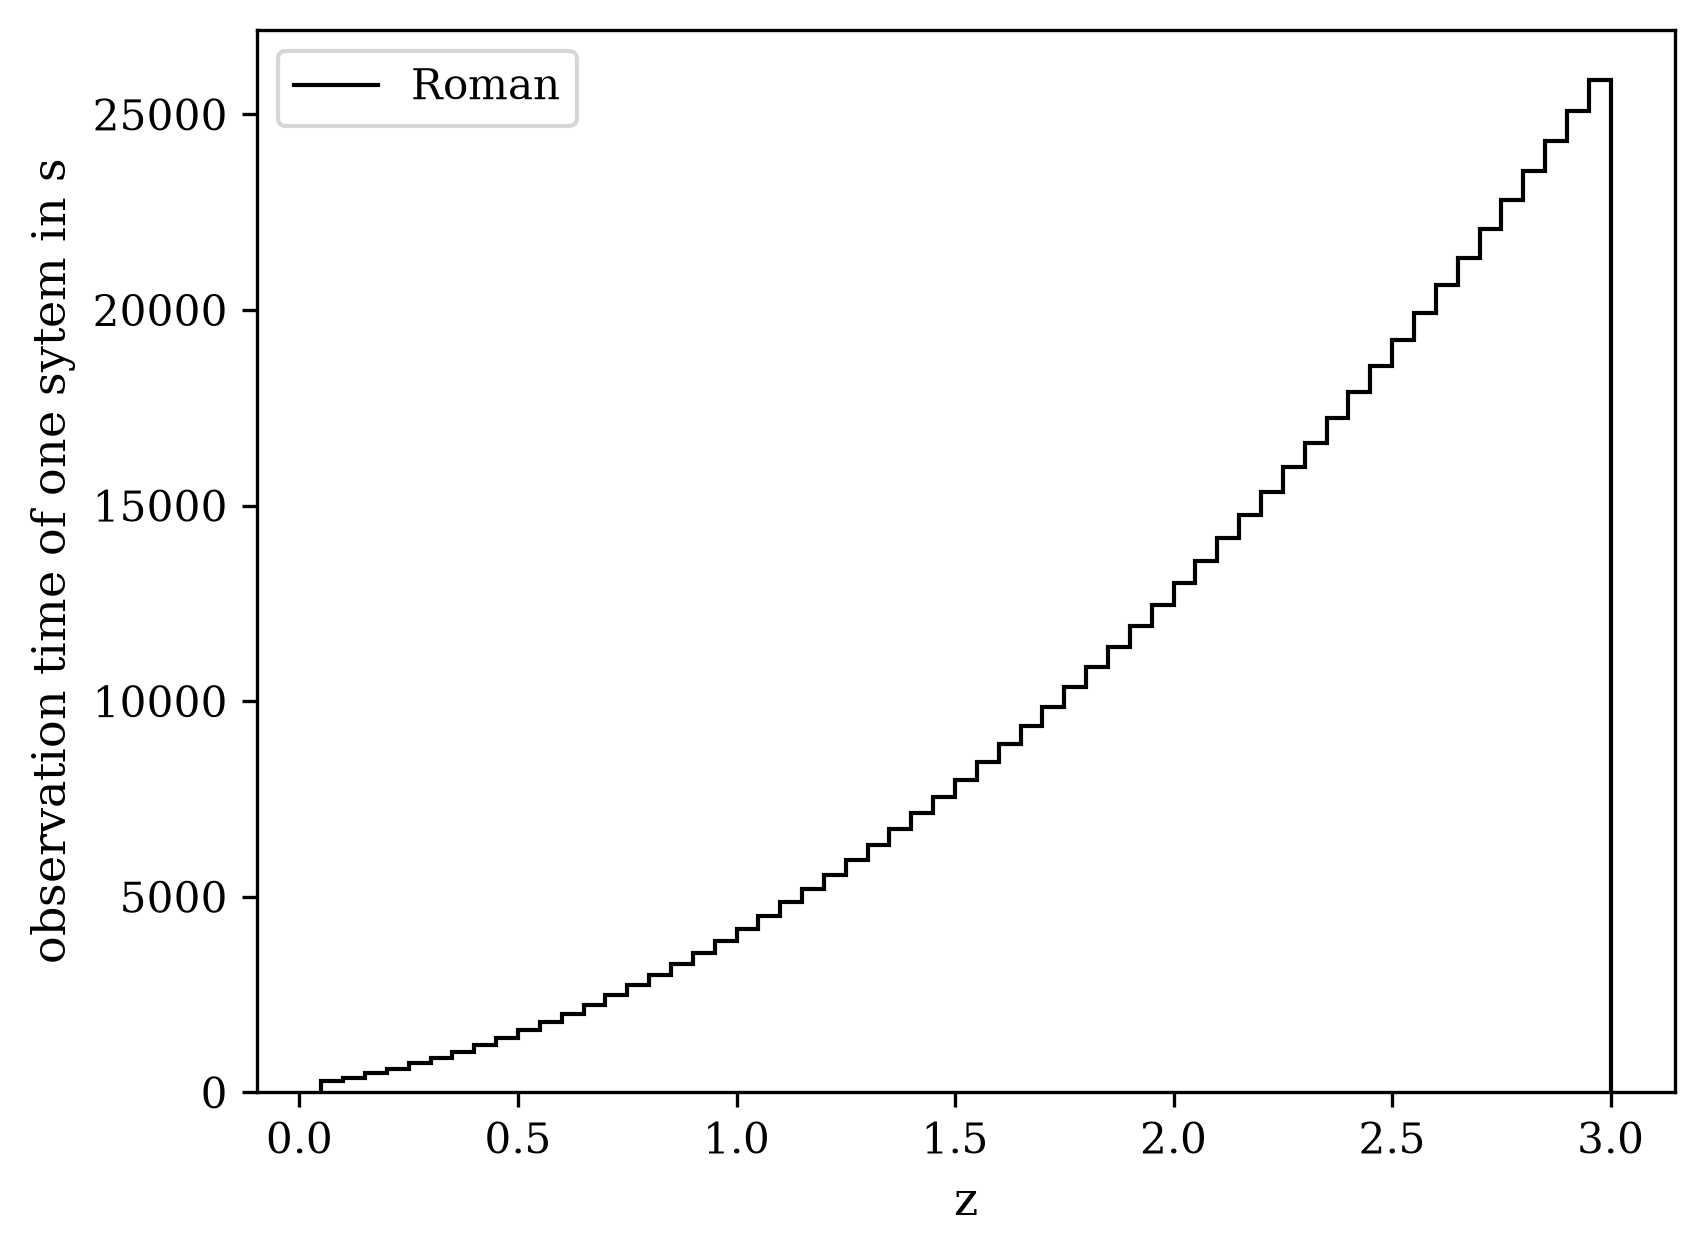

In [19]:
tt_in_hour = tt/3600


plt.stairs(tt, z_edges, label="Roman", color="black")
plt.xlabel("z")
plt.ylabel("observation time of one sytem in s")
plt.legend(loc='upper left')
##plt.savefig('figures/roman_observation_time')
plt.show()

# 2. Optimisation

In [20]:
cosmo = cosmo_fCPL
cosmo_name = 'fCPL'
fiducial_cosmo = fiducial_fCPL

In [21]:
# fix H0, vary Mb
H0 = H0_fid

In [22]:
num_params=len(fiducial_cosmo)

In [23]:
fiducial_cosmo, cosmo_name

([0.3153, -1.029, 0.21, -19.3], 'fCPL')

In [24]:
# for fCPL only:
h = np.array([
            1e-3,   # Om0
            1e-2,   # w0
            5e-2,   # wa
            1e-3    # Mb
        ])

In [25]:
def get_FOM(fiducial_cosmo,Cov_inv_roman,z_roman,cosmo_name,H0):

    FF = fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_roman,z_roman,cosmo_name,H0)
    CC = fma.marginalize_fisher_matrix(FF, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])
    AA = fma.ellipse_parameters(CC, 0.32)[3] #area
    FOM = 1/AA
    
    return FOM

In [26]:
FF = fma.fisher_matrix_observable(fiducial_cosmo,Cov_inv_roman,z_roman,cosmo_name,H0)
FF

array([[ 30550.74537293,   9947.31885081,   1892.13024034,
        -21953.37065059],
       [  9947.31885081,   3689.34791854,    648.86610168,
         -6999.30189908],
       [  1892.13024034,    648.86610168,    126.44977437,
         -1164.71617313],
       [-21953.37065059,  -6999.30189908,  -1164.71617313,
         26616.2800282 ]])

In [27]:
fma.is_positive_definite(FF)

True

In [28]:
def F_prior(sigma_w0,sigma_wa):
    Fp = np.diag([0,1/sigma_w0**2, 1/sigma_wa**2,0])
    return Fp


In [29]:
II = np.eye(FF.shape[0])
CC_full = np.linalg.solve(FF, II)
CC_full

array([[ 1.06450398e-03,  1.92857607e-04, -1.40113971e-02,
         3.15597004e-04],
       [ 1.92857607e-04,  3.43719427e-03, -1.79797427e-02,
         2.76166987e-04],
       [-1.40113971e-02, -1.79797427e-02,  2.67752273e-01,
        -4.56816793e-03],
       [ 3.15597004e-04,  2.76166987e-04, -4.56816793e-03,
         1.70601416e-04]])

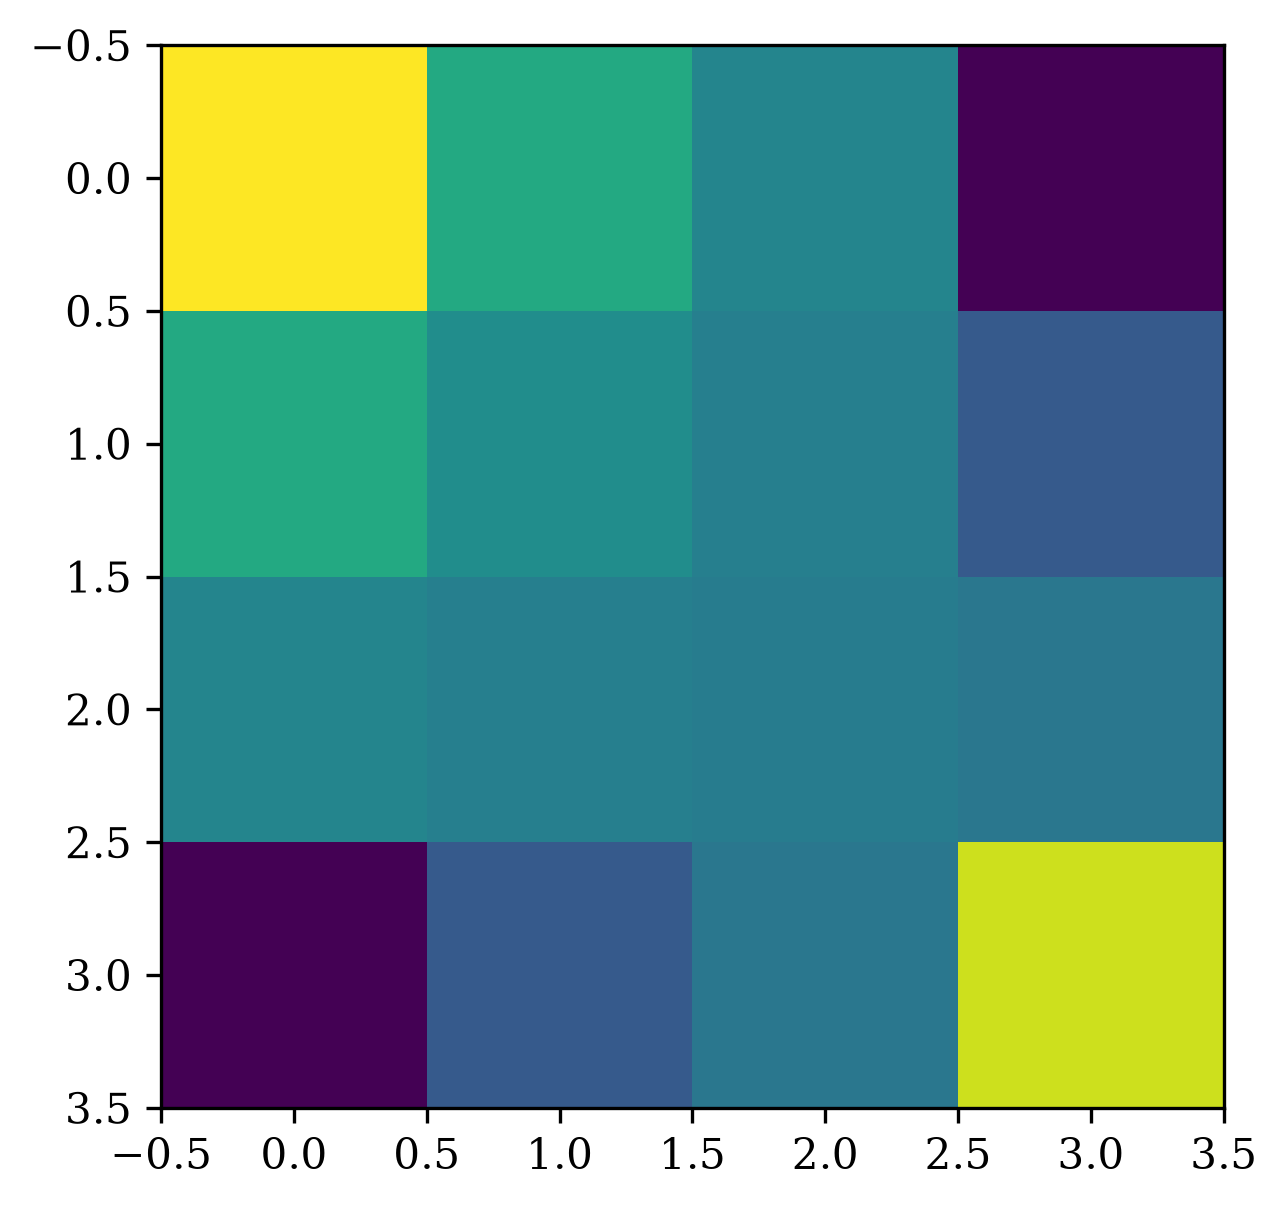

In [30]:
plt.imshow(FF)

In [31]:
fma.is_positive_definite(CC_full)

True

In [32]:
CC = fma.marginalize_fisher_matrix(FF, ('w0','wa'), ['Om0', 'w0', 'wa', 'Mb'])

In [33]:
AA = fma.ellipse_parameters(CC, 0.32)[3] #area
FOM = 1/AA
np.savez('FOM_original',FOM)

$$
\mathrm{FoM} = \frac{1}{\pi \, \Delta\chi^2 \, \sqrt{\det \mathbf{C}}}
$$

At 68% confidence level, $\Delta\chi^2 \simeq 2.279$.

In [34]:
FOM, 1/(np.pi * sc.stats.chi2.ppf(0.68, df=2) * np.sqrt(np.linalg.det(CC)))

(np.float64(5.716459864819853), np.float64(5.716459864819845))

In [35]:
AA

np.float64(0.17493344196365032)

In [36]:
T0 = (dist_roman_without_lsst*tt).sum()
T0

np.float64(79668751.29764733)

In [37]:
z_roman[39]

np.float64(2.025)

In [38]:
limit_low_redshift = np.full_like(dist_roman, 10)
limit_low_redshift[39:] = NIa_tot.copy()[39:]
dist_roman_fake_without_lsst = opt.fake_roman_distribution(z_roman, tt, limit_low_redshift, T0)
dist_roman_fake = dist_roman_fake_without_lsst + lsst_SNIa


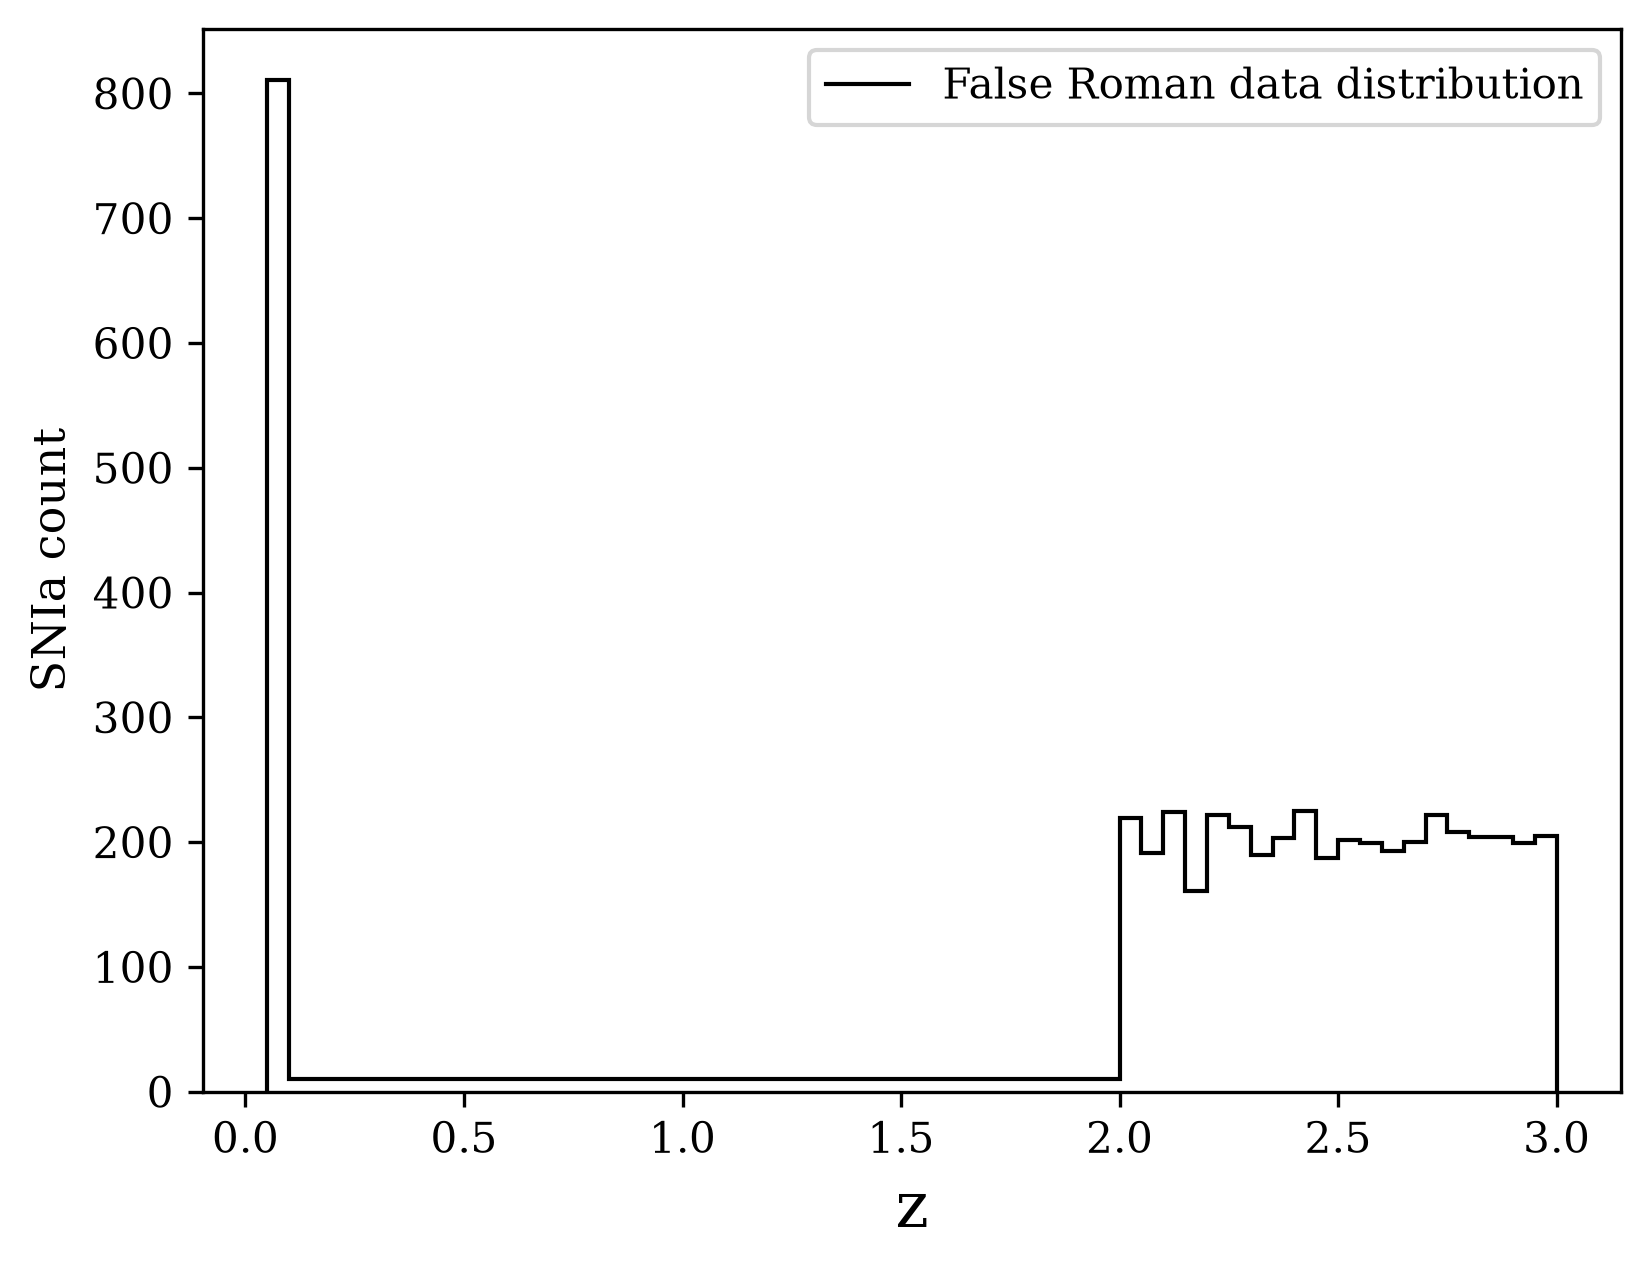

In [39]:
Cov_roman_fake = opt_jax.build_covariance(dist_roman_fake, dist_roman, Cov_roman_stat, Cov_roman_sys)
Cov_roman_stat_fake = Cov_roman_fake-Cov_roman_sys
Cov_inv_roman_fake = jnp.linalg.solve(Cov_roman_fake,np.eye(Cov_roman_fake.shape[0]))
FF_fake = opt_jax.fisher_matrix_observable(fiducial_cosmo, Cov_inv_roman_fake, z_roman, H0)
II_fake = np.eye(FF_fake.shape[0])
CC_fake = opt_jax.marginalize_fisher_matrix(FF_fake,param_tuple=('w0', 'wa'),param_names=['Om0', 'w0', 'wa', 'Mb'])
AA_fake = opt_jax.ellipse_parameters(CC_fake, 0.32)[3] #area
FOM_fake = 1/AA_fake

# plot
plt.stairs(dist_roman_fake, z_edges, label="False Roman data distribution", color="black")
plt.xlabel("z",size=15)
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [40]:
z_edges

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 ,
       1.15, 1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65,
       1.7 , 1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 ,
       2.25, 2.3 , 2.35, 2.4 , 2.45, 2.5 , 2.55, 2.6 , 2.65, 2.7 , 2.75,
       2.8 , 2.85, 2.9 , 2.95, 3.  ])

In [41]:
fma.ellipse_parameters(CC_fake, 0.32)

(np.float64(1.543258529992733),
 np.float64(0.12218543123726303),
 np.float64(94.01662039250556),
 np.float64(0.5923903629209646))

In [42]:
np.savez('dist_roman_fake_nolowz', 
         dist=dist_roman_fake, 
         FOM=1/fma.ellipse_parameters(CC_fake, 0.32)[3], 
         FF = FF_fake, 
         Cov_stat = Cov_roman_stat_fake,
         Cov_sys = Cov_roman_sys)
np.savez('dist_roman_original', 
         dist=dist_roman, 
         FOM=FOM, 
         FF = FF,
         Cov_stat = Cov_roman_stat,
         Cov_sys = Cov_roman_sys)

In [43]:
# fma.is_positive_definite(Cov_roman_stat_fake)

In [44]:
SNIa_count_file = np.load('SNIa_count.npz')
NIa_tot = SNIa_count_file['NIa_tot']

In [45]:
# nb_iter = 5000
# perturbation = 1

# results = opt.optimize_bins_again(
#     nb_iter=nb_iter,
#     perturbation=perturbation,
#     dist_roman=dist_roman,
#     Cov_roman=Cov_roman,
#     Cov_roman_stat=Cov_roman_stat,
#     Cov_roman_sys=Cov_roman_sys,
#     FOM=FOM,
#     H0=H0,
#     z_roman=z_roman,
#     tt=tt,
#     fiducial_cosmo=fiducial_cosmo,
#     param_tuple=('w0', 'wa'),
#     param_names=['Om0', 'w0', 'wa', 'Mb'],
#     NIa_tot=NIa_tot,
#     cosmo_name=cosmo_name,
#     use_marginalization=True,
#     verbose=False
# )




In [46]:
nb_iter = 25000

results = opt_jax.optimize_bins_again_jax(
    nb_iter=nb_iter,
    perturbation=1.0,
    dist_roman=dist_roman,
    Cov_roman=Cov_roman,
    Cov_roman_stat=Cov_roman_stat,
    Cov_roman_sys=Cov_roman_sys,
    FOM=FOM,
    H0=H0,
    z_roman=z_roman,
    tt=tt,
    fiducial_cosmo=fiducial_cosmo,
    param_tuple=("w0", "wa"),
    param_names=("Om0", "w0", "wa", "Mb"),
    NIa_tot=NIa_tot,
    use_marginalization=True,
    verbose=True,
)


Optimizing bins:   0%|          | 0/25000 [00:00<?, ?iter/s]

In [47]:
# nb_iter = 25000
# perturbation = 1

# results = opt_jax.optimize_bins_again_jax(
#     nb_iter=nb_iter,
#     perturbation=perturbation,
#     dist_roman=dist_roman_fake,
#     Cov_roman=Cov_roman_fake,
#     Cov_roman_stat=Cov_roman_stat_fake,
#     Cov_roman_sys=Cov_roman_sys,
#     FOM=FOM_fake,
#     H0=H0,
#     z_roman=z_roman,
#     tt=tt,
#     fiducial_cosmo=fiducial_cosmo,
#     param_tuple=('w0', 'wa'),
#     param_names=['Om0', 'w0', 'wa', 'Mb'],
#     NIa_tot=NIa_tot,
#     use_marginalization=True,
#     verbose=False
# )



In [48]:
optimized_dist       =  results["optimized_dist"]

track_distribution   = results["track_distribution"]
track_delta_n        = results["track_delta_n"]
# track_Cov            = results["track_Cov"]
track_dFOM           = results["track_dFOM"]
# track_dFOM_triche    = results["track_dFOM_triche"]
track_kk             = results["track_kk"]
track_FF             = results["track_FF"]
track_ellipse        = results["track_ellipse"]


In [49]:
# save_path = f"arguments.npz"

# np.savez_compressed(
#     save_path,

#     # --- Input arguments ---
#     nb_iter=nb_iter,
#     perturbation=perturbation,
#     dist_roman=dist_roman,
#     Cov_roman=Cov_roman,
#     Cov_roman_stat=Cov_roman_stat,
#     Cov_roman_sys=Cov_roman_sys,
#     FOM=FOM,
#     H0=H0,
#     z_roman=z_roman,
#     tt=tt,
#     fiducial_cosmo=fiducial_cosmo,
#     param_tuple=('w0', 'wa'),
#     param_names=['Om0', 'w0', 'wa', 'Mb'],
#     cosmo_name=cosmo_name,
#     use_marginalization=True,
#     verbose=False
# )

# print(f"Saved results to: {save_path}")

In [50]:
save_as = "results/optimization_tracks_jax25000_fCPL.npz"
np.savez_compressed(
    save_as,
    track_ellipse = track_ellipse,
    track_FF = track_FF,
    track_distribution = track_distribution,
    track_delta_n = track_delta_n,
    # track_Cov = track_Cov,
    track_dFOM = track_dFOM,
    # track_dFOM_triche = track_dFOM_triche,
    track_kk = track_kk,
)

print("All tracking arrays saved to", save_as)

All tracking arrays saved to results/optimization_tracks_jax25000_fCPL.npz


In [51]:
track_data = np.load("results/optimization_tracks_jax25000_fCPL.npz")

track_ellipse = track_data["track_ellipse"]
track_FF = track_data["track_FF"]
track_distribution = track_data["track_distribution"]
track_delta_n = track_data["track_delta_n"]
#track_Cov = track_data["track_Cov"]
track_dFOM = track_data["track_dFOM"]
#track_dFOM_triche = track_data["track_dFOM_triche"]
track_kk = track_data["track_kk"]
optimized_dist = track_distribution[-1]

print("All tracking arrays successfully loaded")


All tracking arrays successfully loaded


In [52]:
track_distribution[-1]

array([8.11000000e+02, 2.40000000e+01, 5.30000000e+01, 8.40859673e+01,
       1.22599978e+02, 1.66277866e+02, 2.13891237e+02, 2.64873058e+02,
       3.19174111e+02, 3.75305605e+02, 4.33275935e+02, 4.91982546e+02,
       5.51279407e+02, 6.10730167e+02, 6.69799701e+02, 7.28295455e+02,
       7.83175353e-02, 3.20224699e+02, 8.97860216e+02, 9.51822078e+02,
       8.06367866e-01, 1.05522620e+03, 1.10454784e+03, 1.15216864e+03,
       6.15658778e+02, 2.32401302e-01, 7.28575039e-02, 1.84460551e-01,
       1.15365742e+00, 6.75204803e-01, 2.43805081e-02, 7.49194569e-02,
       3.64714362e-01, 1.91246862e-02, 1.04475686e-01, 1.85675219e-01,
       6.55924710e-03, 1.97991785e-01, 1.97802728e-02, 4.33179012e-01,
       7.21164126e-02, 7.76464846e-03, 5.48336306e-01, 1.92998205e-01,
       5.73217558e+02, 1.15461809e-01, 9.67416439e+02, 9.49379146e-01,
       7.37217198e+02, 7.73241334e-02, 3.26904461e-02, 5.31264440e-01,
       4.04122567e-01, 7.93501653e-04, 5.72327895e-01, 5.82911341e-01,
      

In [53]:
obs_time_opt = (optimized_dist*tt).sum()
print('Original observation time:', obs_time_roman)
print('Observation time after optimization', obs_time_opt)
print('Observation time ratio:', obs_time_opt/obs_time_roman)

Original observation time: 79893117.41864456
Observation time after optimization 79893117.41864467
Observation time ratio: 1.0000000000000013


In [54]:
print('area ratio new/ref', track_ellipse[-1][3]/AA_fake)

area ratio new/ref 0.24476577663150292


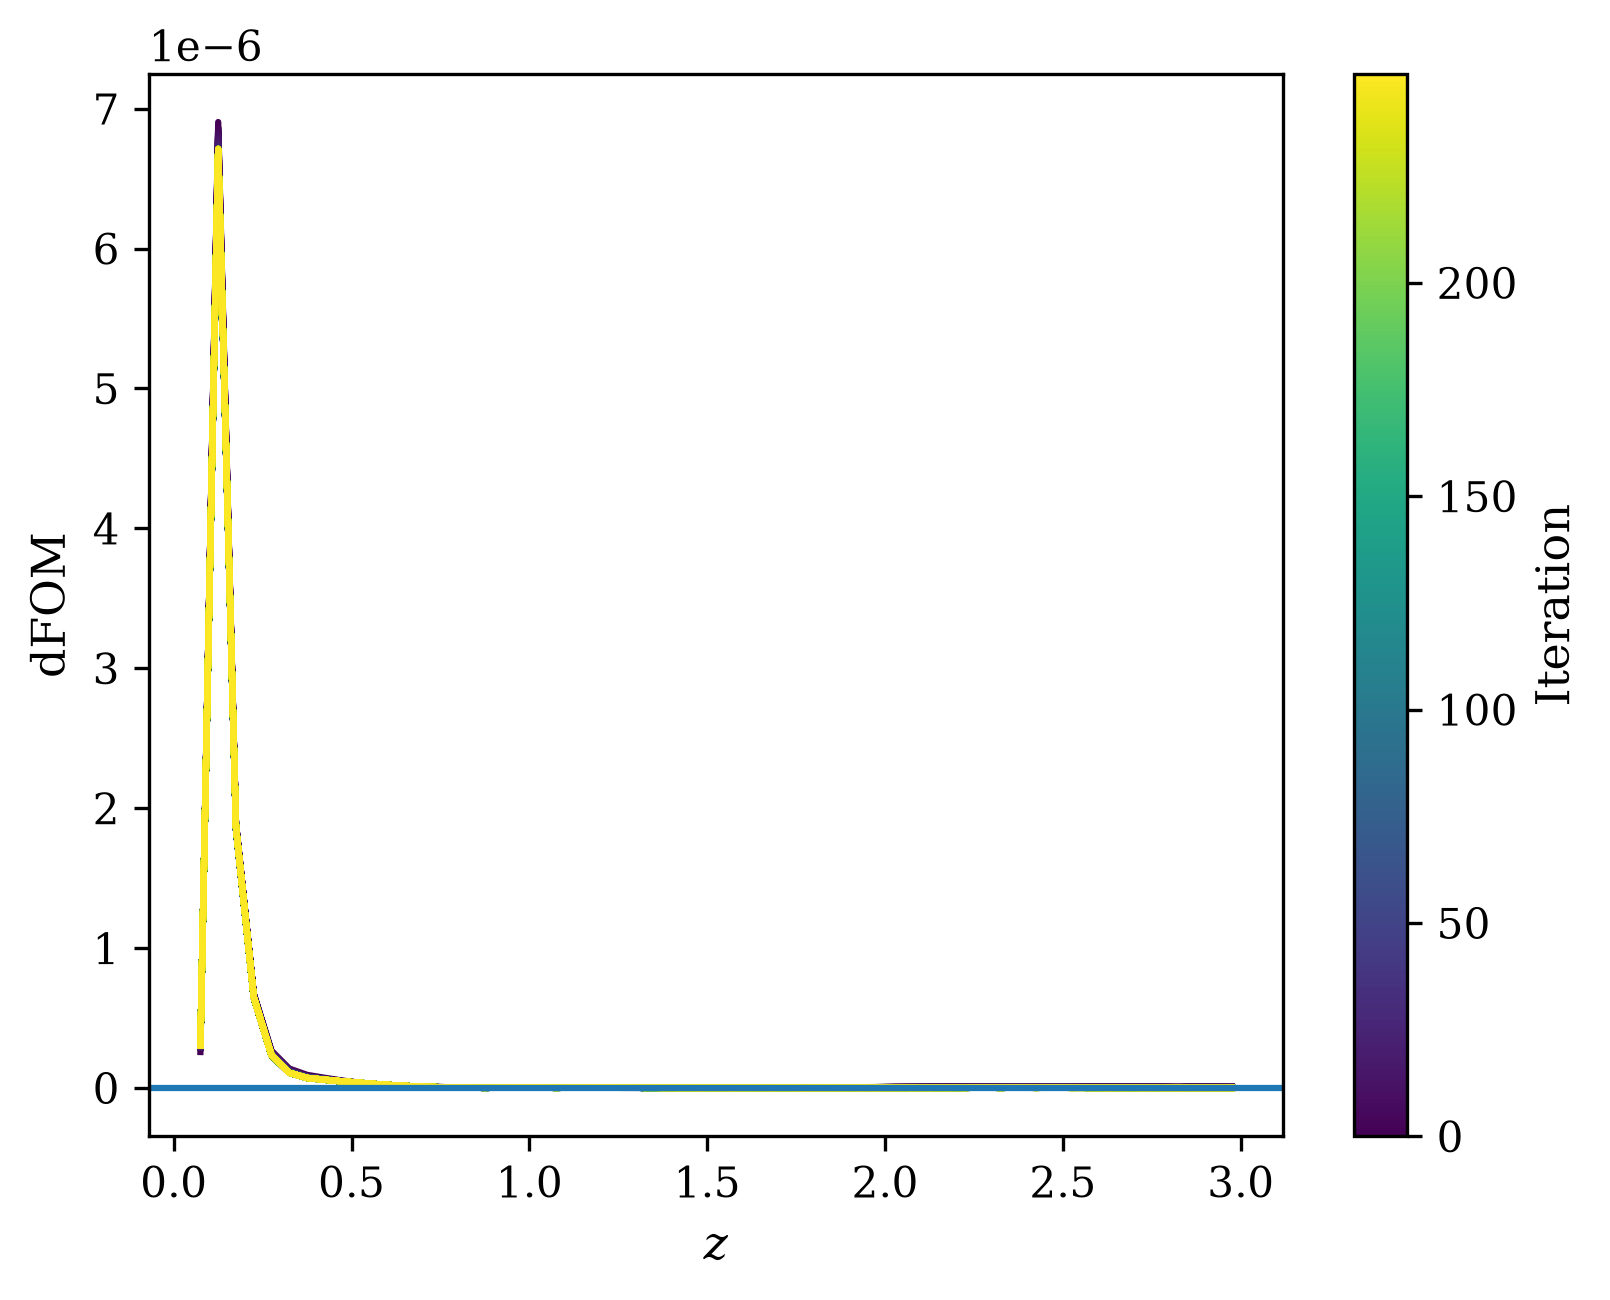

In [55]:
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=track_dFOM.shape[0]-1)

fig, ax = plt.subplots()

for ii in range(track_dFOM.shape[0] - 1):
    ax.plot(
        z_roman,
        track_dFOM[ii]/(1/track_ellipse[ii][3]),
        color=cmap(norm(ii))
    )
# ax.plot(
#         z_roman,
#         track_dFOM[150]/(1/track_ellipse[150][3]),
#         color=cmap(norm(0))
#     )
# ax.plot(
#         z_roman,
#         track_dFOM[151]/(1/track_ellipse[151][3]),
#         color=cmap(norm(0))
#     )
ax.axhline(0)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label='Iteration')
# ax.set_yscale('log')
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\mathrm{dFOM}$')

plt.show()


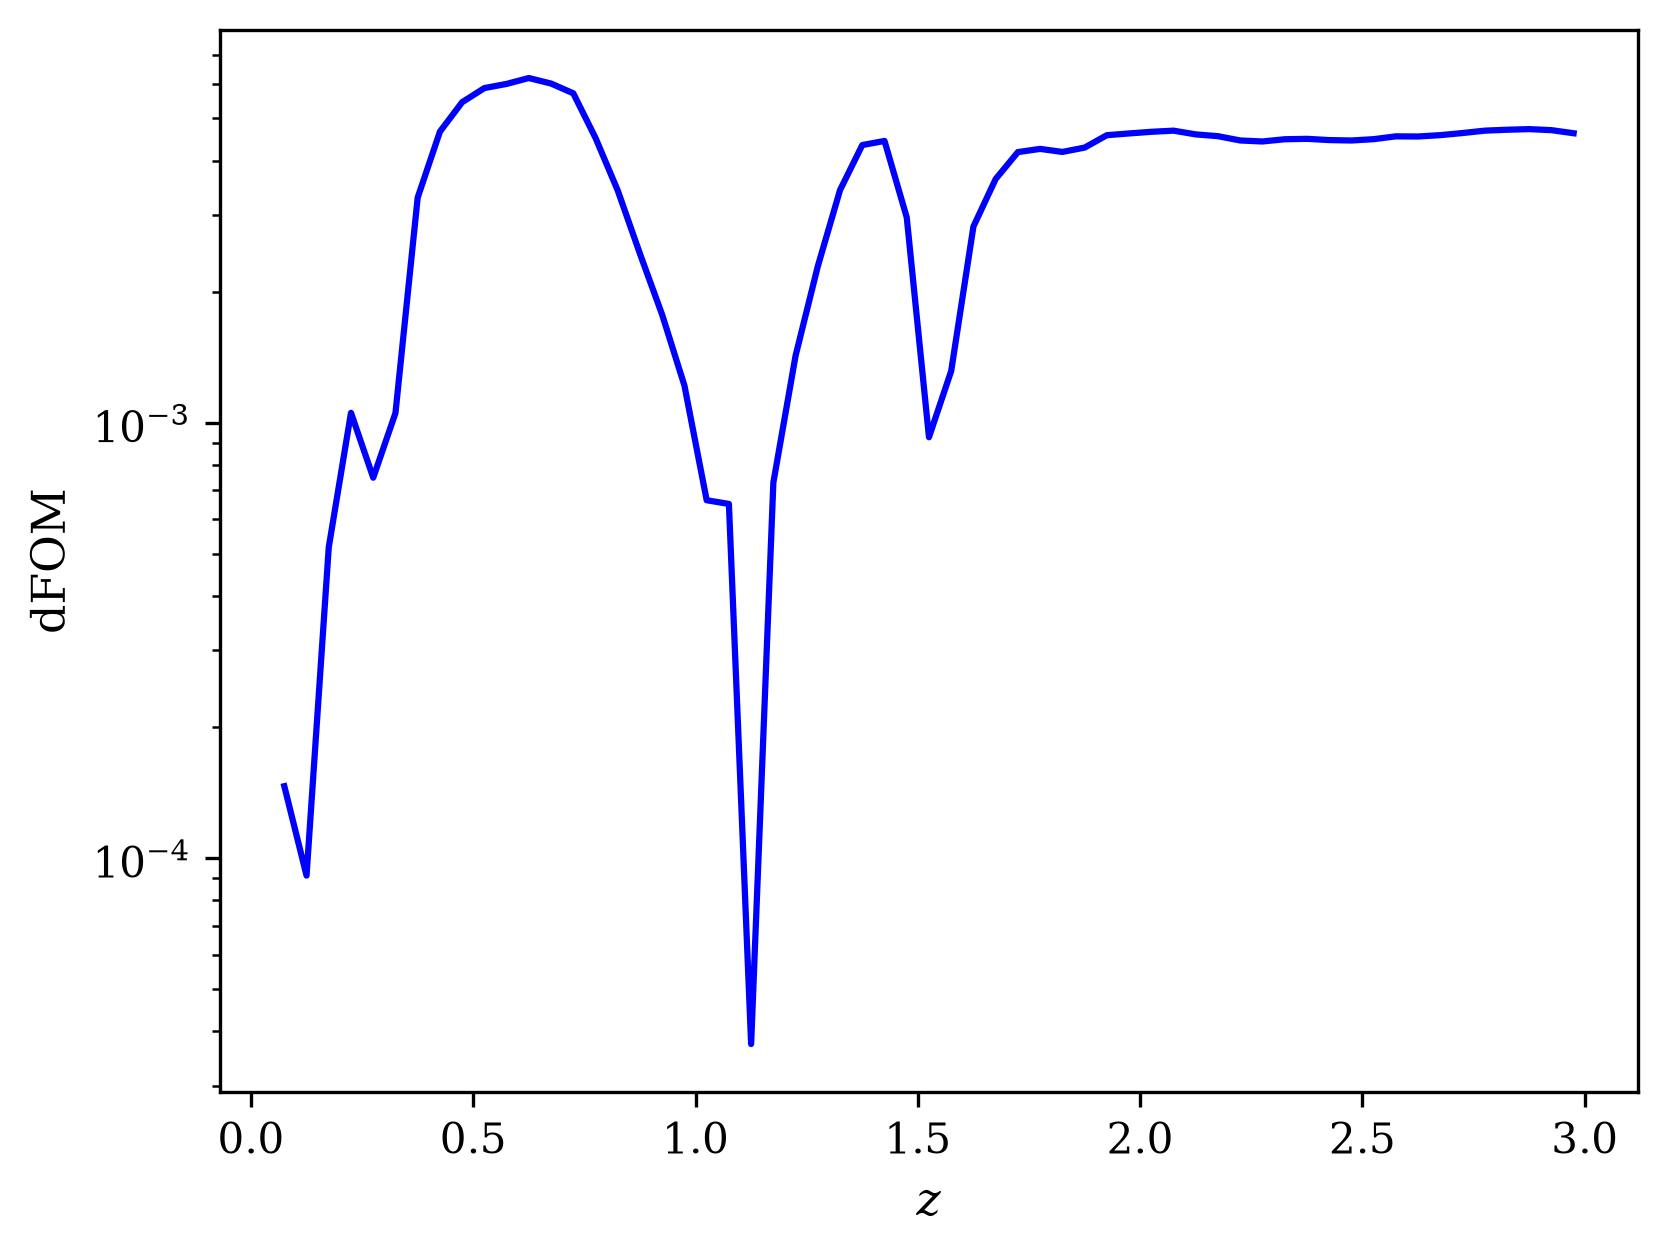

In [56]:
fig, ax = plt.subplots()
nn = 1

# iter nn
ax.plot(
        z_roman,
        np.abs(track_dFOM[nn]/(1/track_ellipse[nn][3])-track_dFOM[nn+1]/(1/track_ellipse[nn+1][3]))/track_dFOM[nn],
        color='blue',
        label='iter n'
    )
# ax.plot(
#         z_roman,
#         track_dFOM[nn+1]/(1/track_ellipse[nn+1][3]),
#         color='red',
#         ls='--',
#         label='iter n+1'
#     )
ax.axhline(0)
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

ax.set_yscale('log')
ax.set_xlabel(r'$z$')
ax.set_ylabel(r'$\mathrm{dFOM}$')

plt.show()


In [57]:
track_dFOM[0]

array([ 1.47411353e-06,  3.95741660e-05,  1.08664128e-05,  3.86933651e-06,
        1.52872240e-06,  7.95535358e-07,  5.38747461e-07,  4.17882152e-07,
        3.03630428e-07,  2.15849978e-07,  1.43496819e-07,  9.03067854e-08,
        5.35511003e-08,  3.13085864e-08,  2.00440968e-08,  1.59881250e-08,
        1.50333320e-08,  1.57224384e-08,  1.67682630e-08,  1.78952626e-08,
        1.16538140e-08,  1.01571603e-08,  8.41670864e-09,  6.29196486e-09,
        3.68474812e-09,  1.85334790e-09,  3.22306714e-10, -7.26861615e-10,
       -7.93312100e-10, -9.04249108e-12,  1.67311121e-09,  4.74577797e-09,
        8.12199439e-09,  1.29582381e-08,  1.96596153e-08,  2.41109702e-08,
        2.92729724e-08,  3.12201837e-08,  3.60655687e-08,  4.32640487e-08,
        4.72043720e-08,  5.02943868e-08,  5.55455147e-08,  6.33271901e-08,
        6.78321601e-08,  6.87097925e-08,  7.57433297e-08,  7.25924487e-08,
        7.59621376e-08,  7.46707985e-08,  5.90304061e-08,  5.34628218e-08,
        5.27600739e-08,  

In [58]:
track_dFOM[-1]

array([2.09122125e-06, 4.62613683e-05, 1.28556607e-05, 4.48094029e-06,
       1.61130267e-06, 7.50818100e-07, 4.95336876e-07, 4.07462759e-07,
       3.24492657e-07, 2.53316472e-07, 1.84357760e-07, 1.26022225e-07,
       8.06371466e-08, 4.94772291e-08, 3.20224184e-08, 2.43668964e-08,
       1.40717911e-09, 2.25605584e-08, 2.61741053e-08, 3.08945727e-08,
       1.47110149e-08, 2.27831894e-08, 2.37041318e-08, 2.40986383e-08,
       2.25624619e-08, 4.48585793e-09, 1.32091448e-09, 3.02721629e-09,
       1.64163045e-08, 9.67447607e-09, 1.41824816e-08, 1.02127962e-09,
       4.74249904e-09, 2.43119749e-10, 1.46673332e-09, 2.72271698e-09,
       1.00051782e-10, 2.63957794e-09, 2.77536324e-10, 6.49055270e-09,
       1.07502103e-09, 1.24690111e-10, 9.42629152e-09, 3.89945068e-09,
       2.25726485e-08, 2.35391031e-09, 2.35792774e-08, 2.01026255e-08,
       2.25725321e-08, 1.65814617e-09, 5.91089286e-10, 9.02666920e-09,
       6.68219132e-09, 1.28492205e-11, 8.88423300e-09, 8.03113201e-09,
      

Text(0, 0.5, '$\\delta n$')

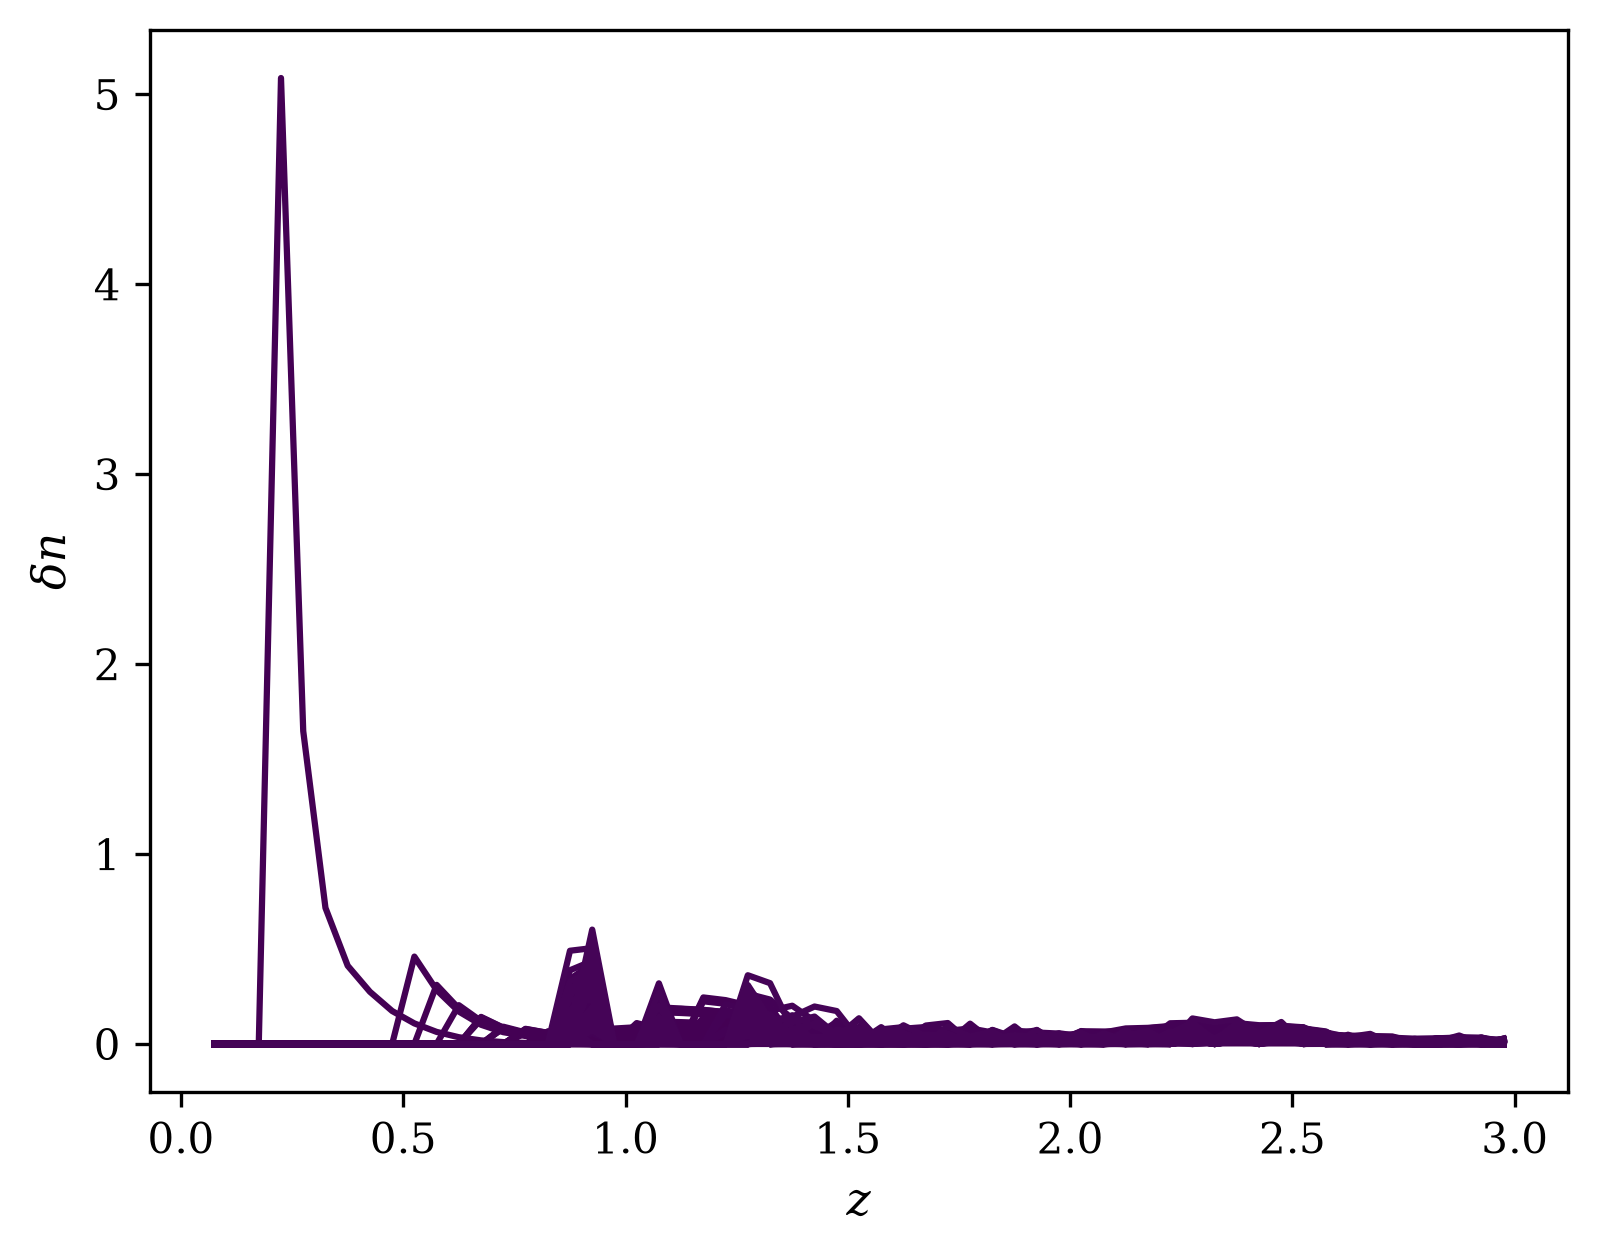

In [59]:
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=nb_iter-1)

for ii in range(track_delta_n.shape[0]-2):
    plt.plot(z_roman, track_delta_n[ii],
                color=cmap(norm(ii)))

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label='Iteration')       

plt.xlabel(r'$z$')
plt.ylabel(r'$\delta n$')

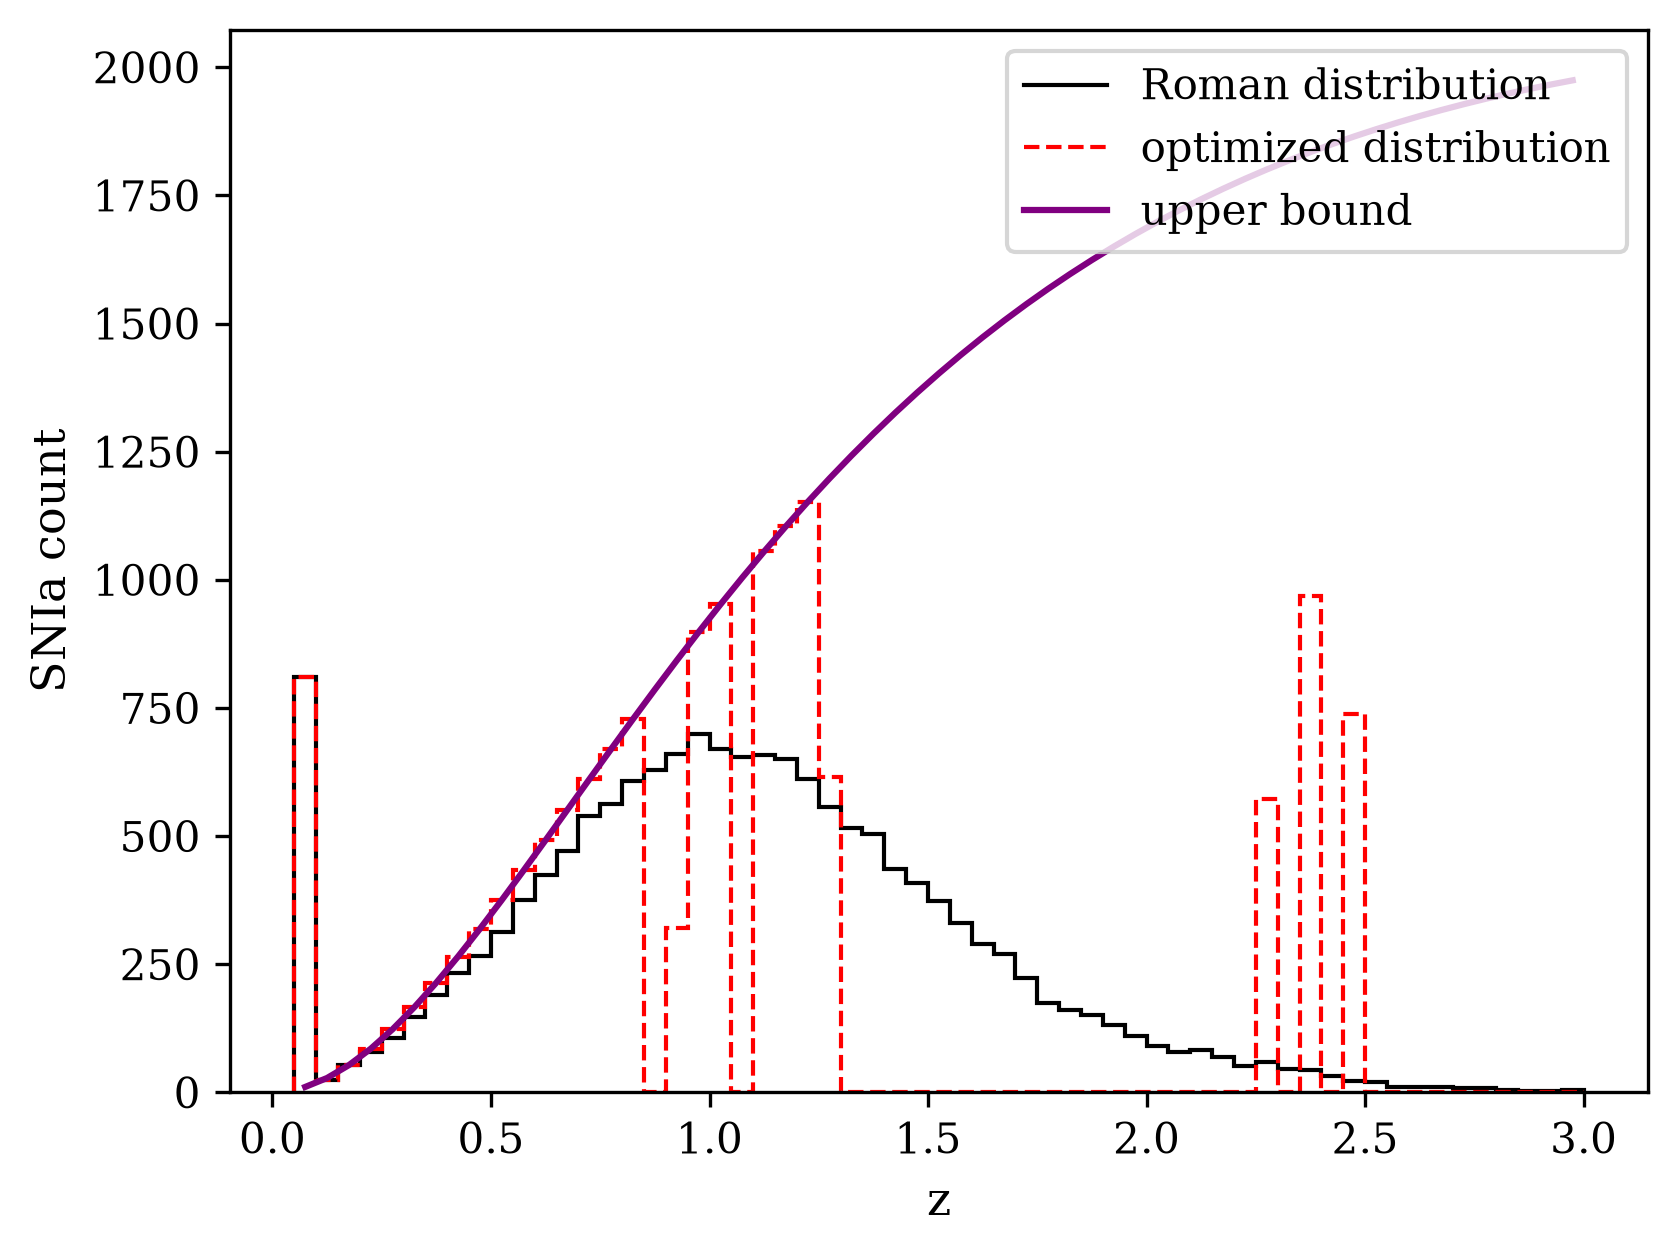

In [60]:
# plot
plt.stairs(dist_roman, z_edges, label="Roman distribution", color="black")
#plt.stairs(dist_roman_fake, z_edges, label="Roman fake distribution", color="blue")
plt.stairs( track_distribution[-1],
            z_edges, label='optimized distribution', color='red', ls='--')
plt.plot(z_roman, NIa_tot, color='purple', label='upper bound')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
#plt.savefig('figures/roman_dist_25000')
plt.show()

Text(0, 0.5, 'FOM')

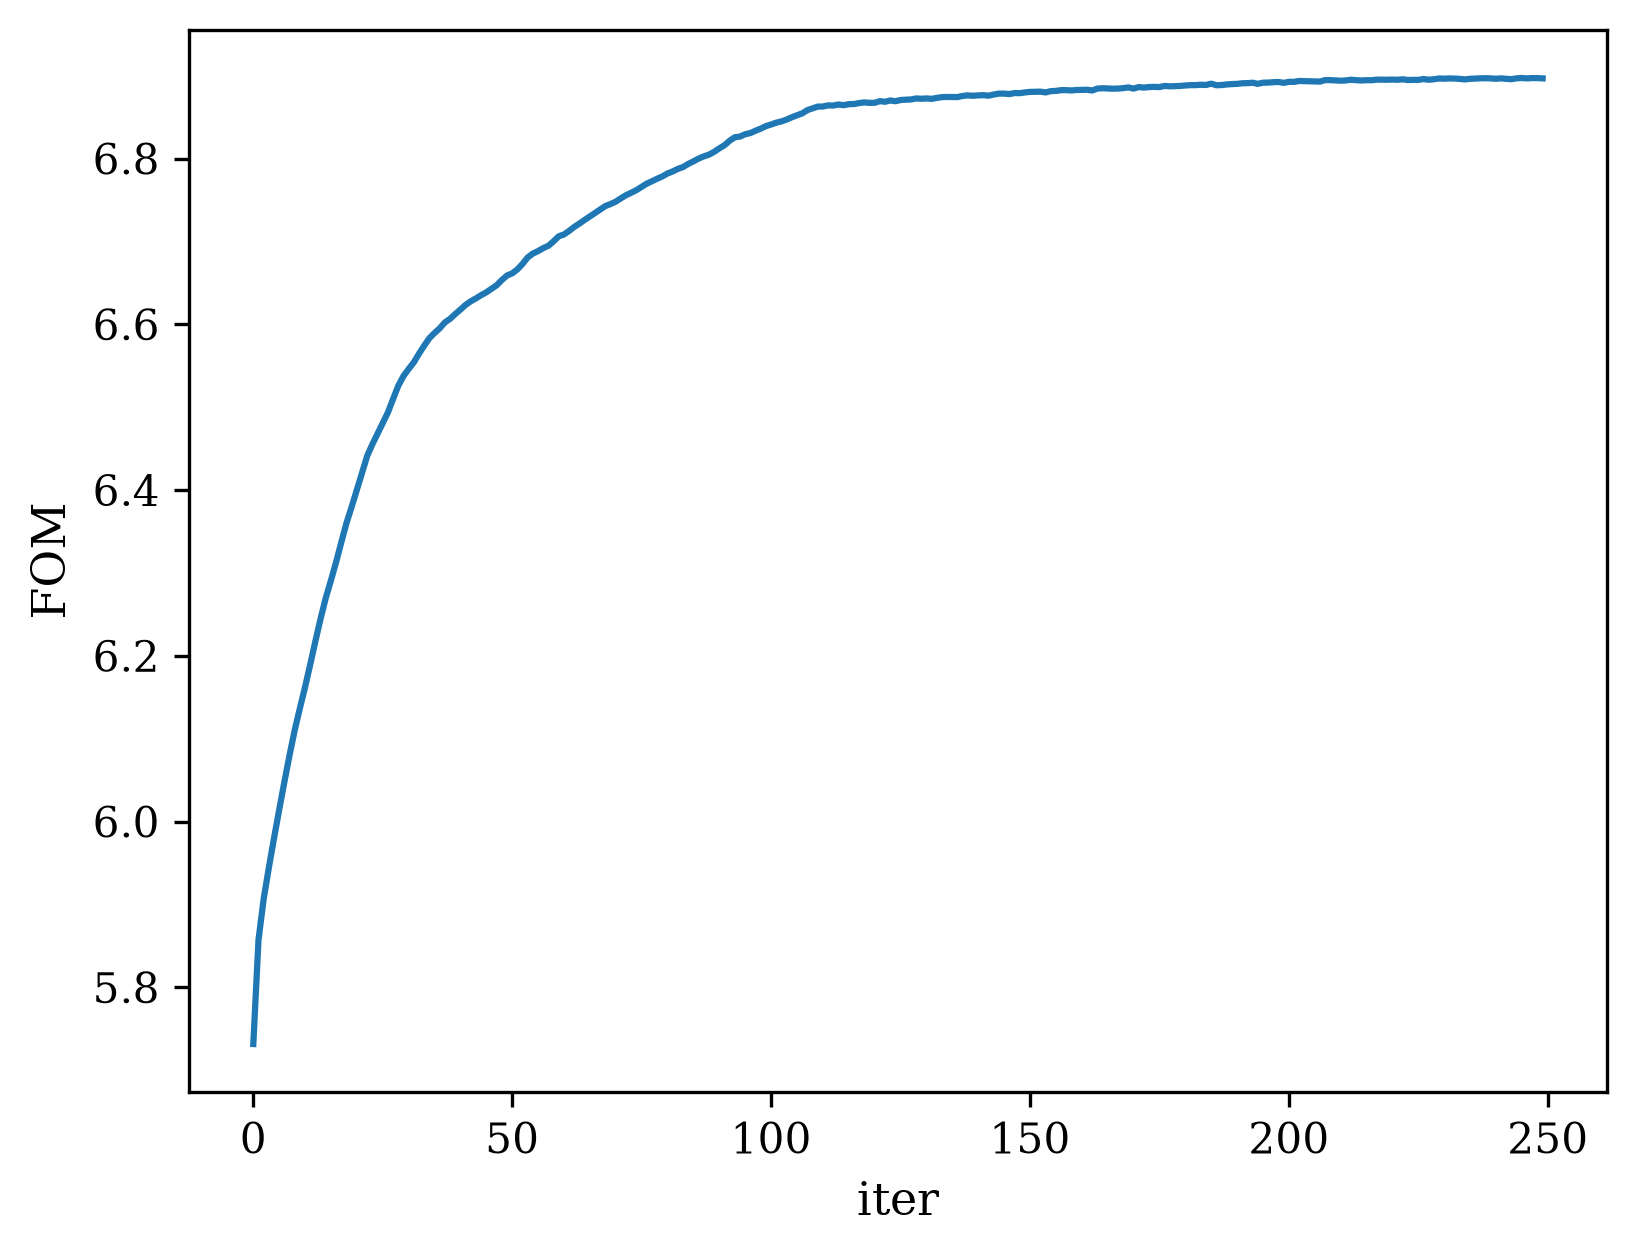

In [61]:
plt.plot(1/track_ellipse[:,3])
plt.xlabel('iter')
plt.ylabel('FOM')
#plt.savefig('figures/track_fom_roman_dist_25000')

Text(0, 0.5, 'iter')

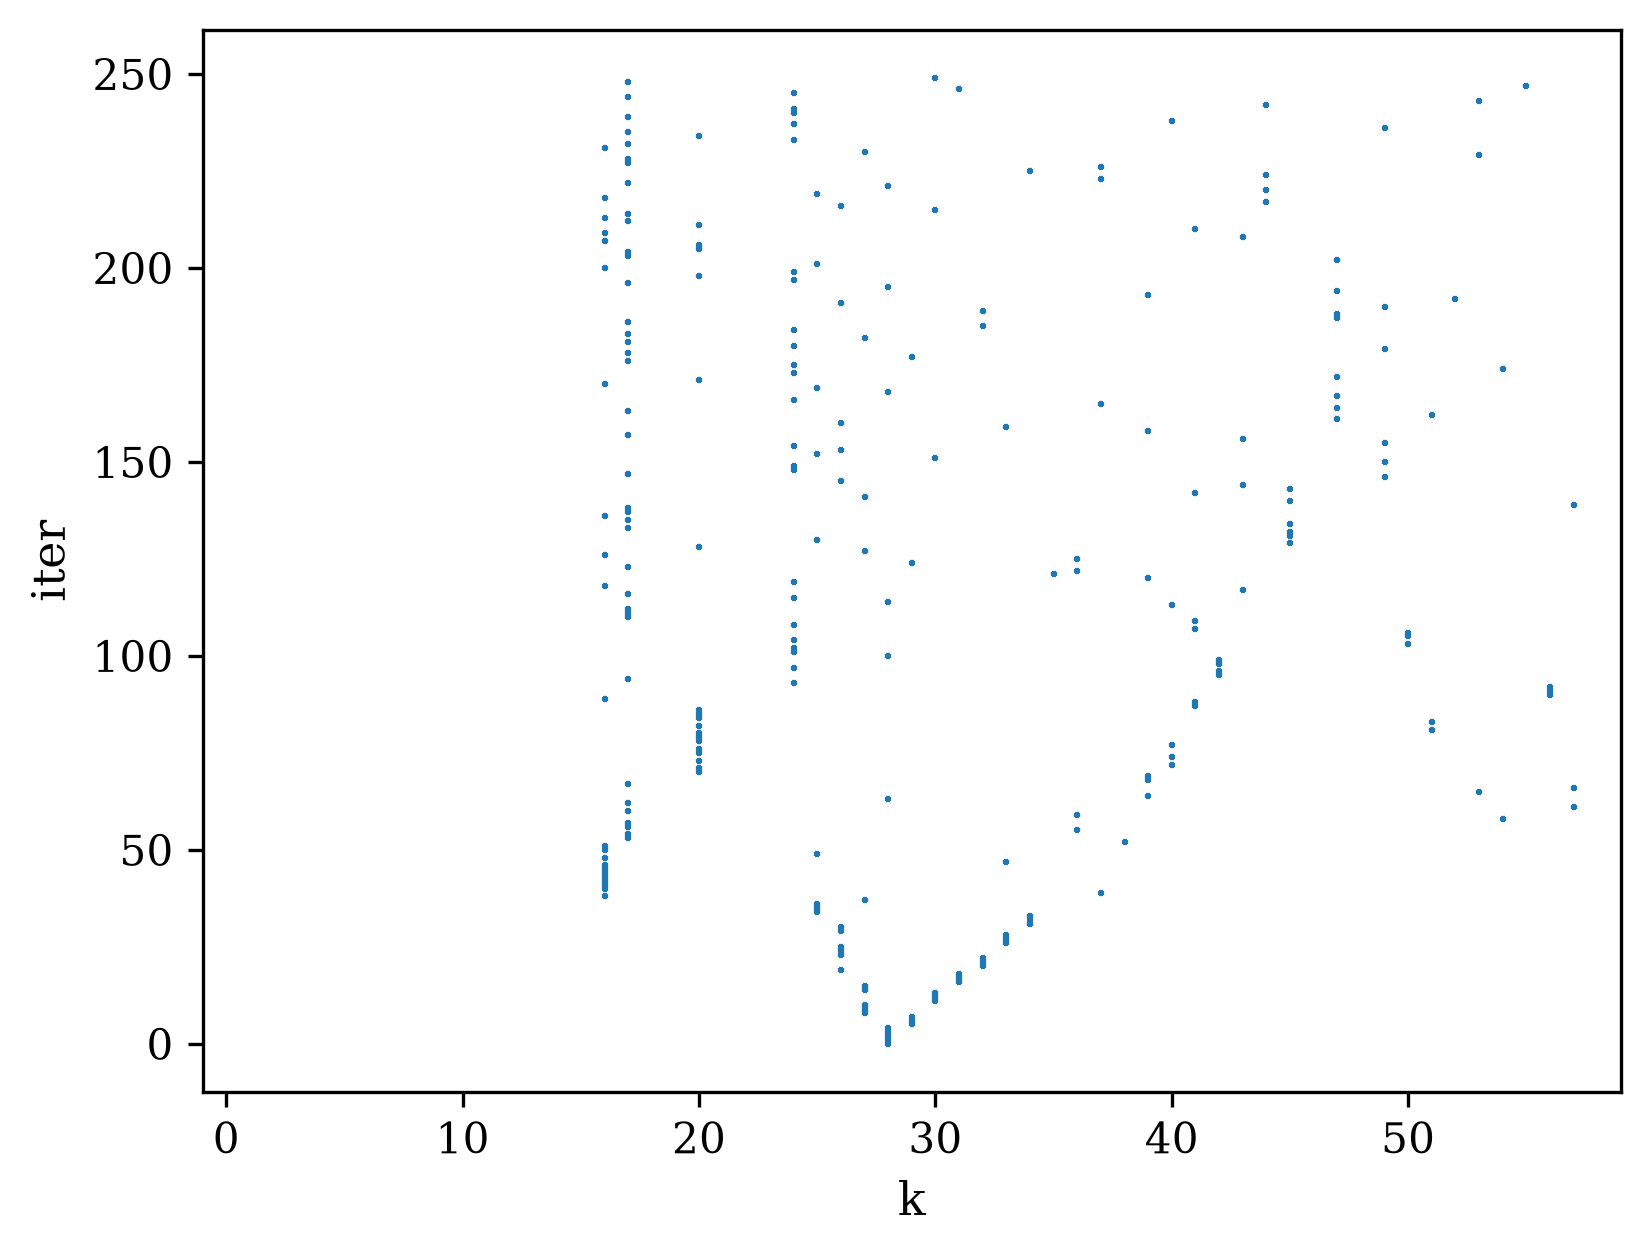

In [62]:
plt.scatter(track_kk,np.arange(0,len(track_kk),1),s=1,marker='+')
plt.xlim(-1,len(z_roman))
plt.xlabel('k')
plt.ylabel('iter')

In [63]:
dist_roman[28]

np.int64(409)

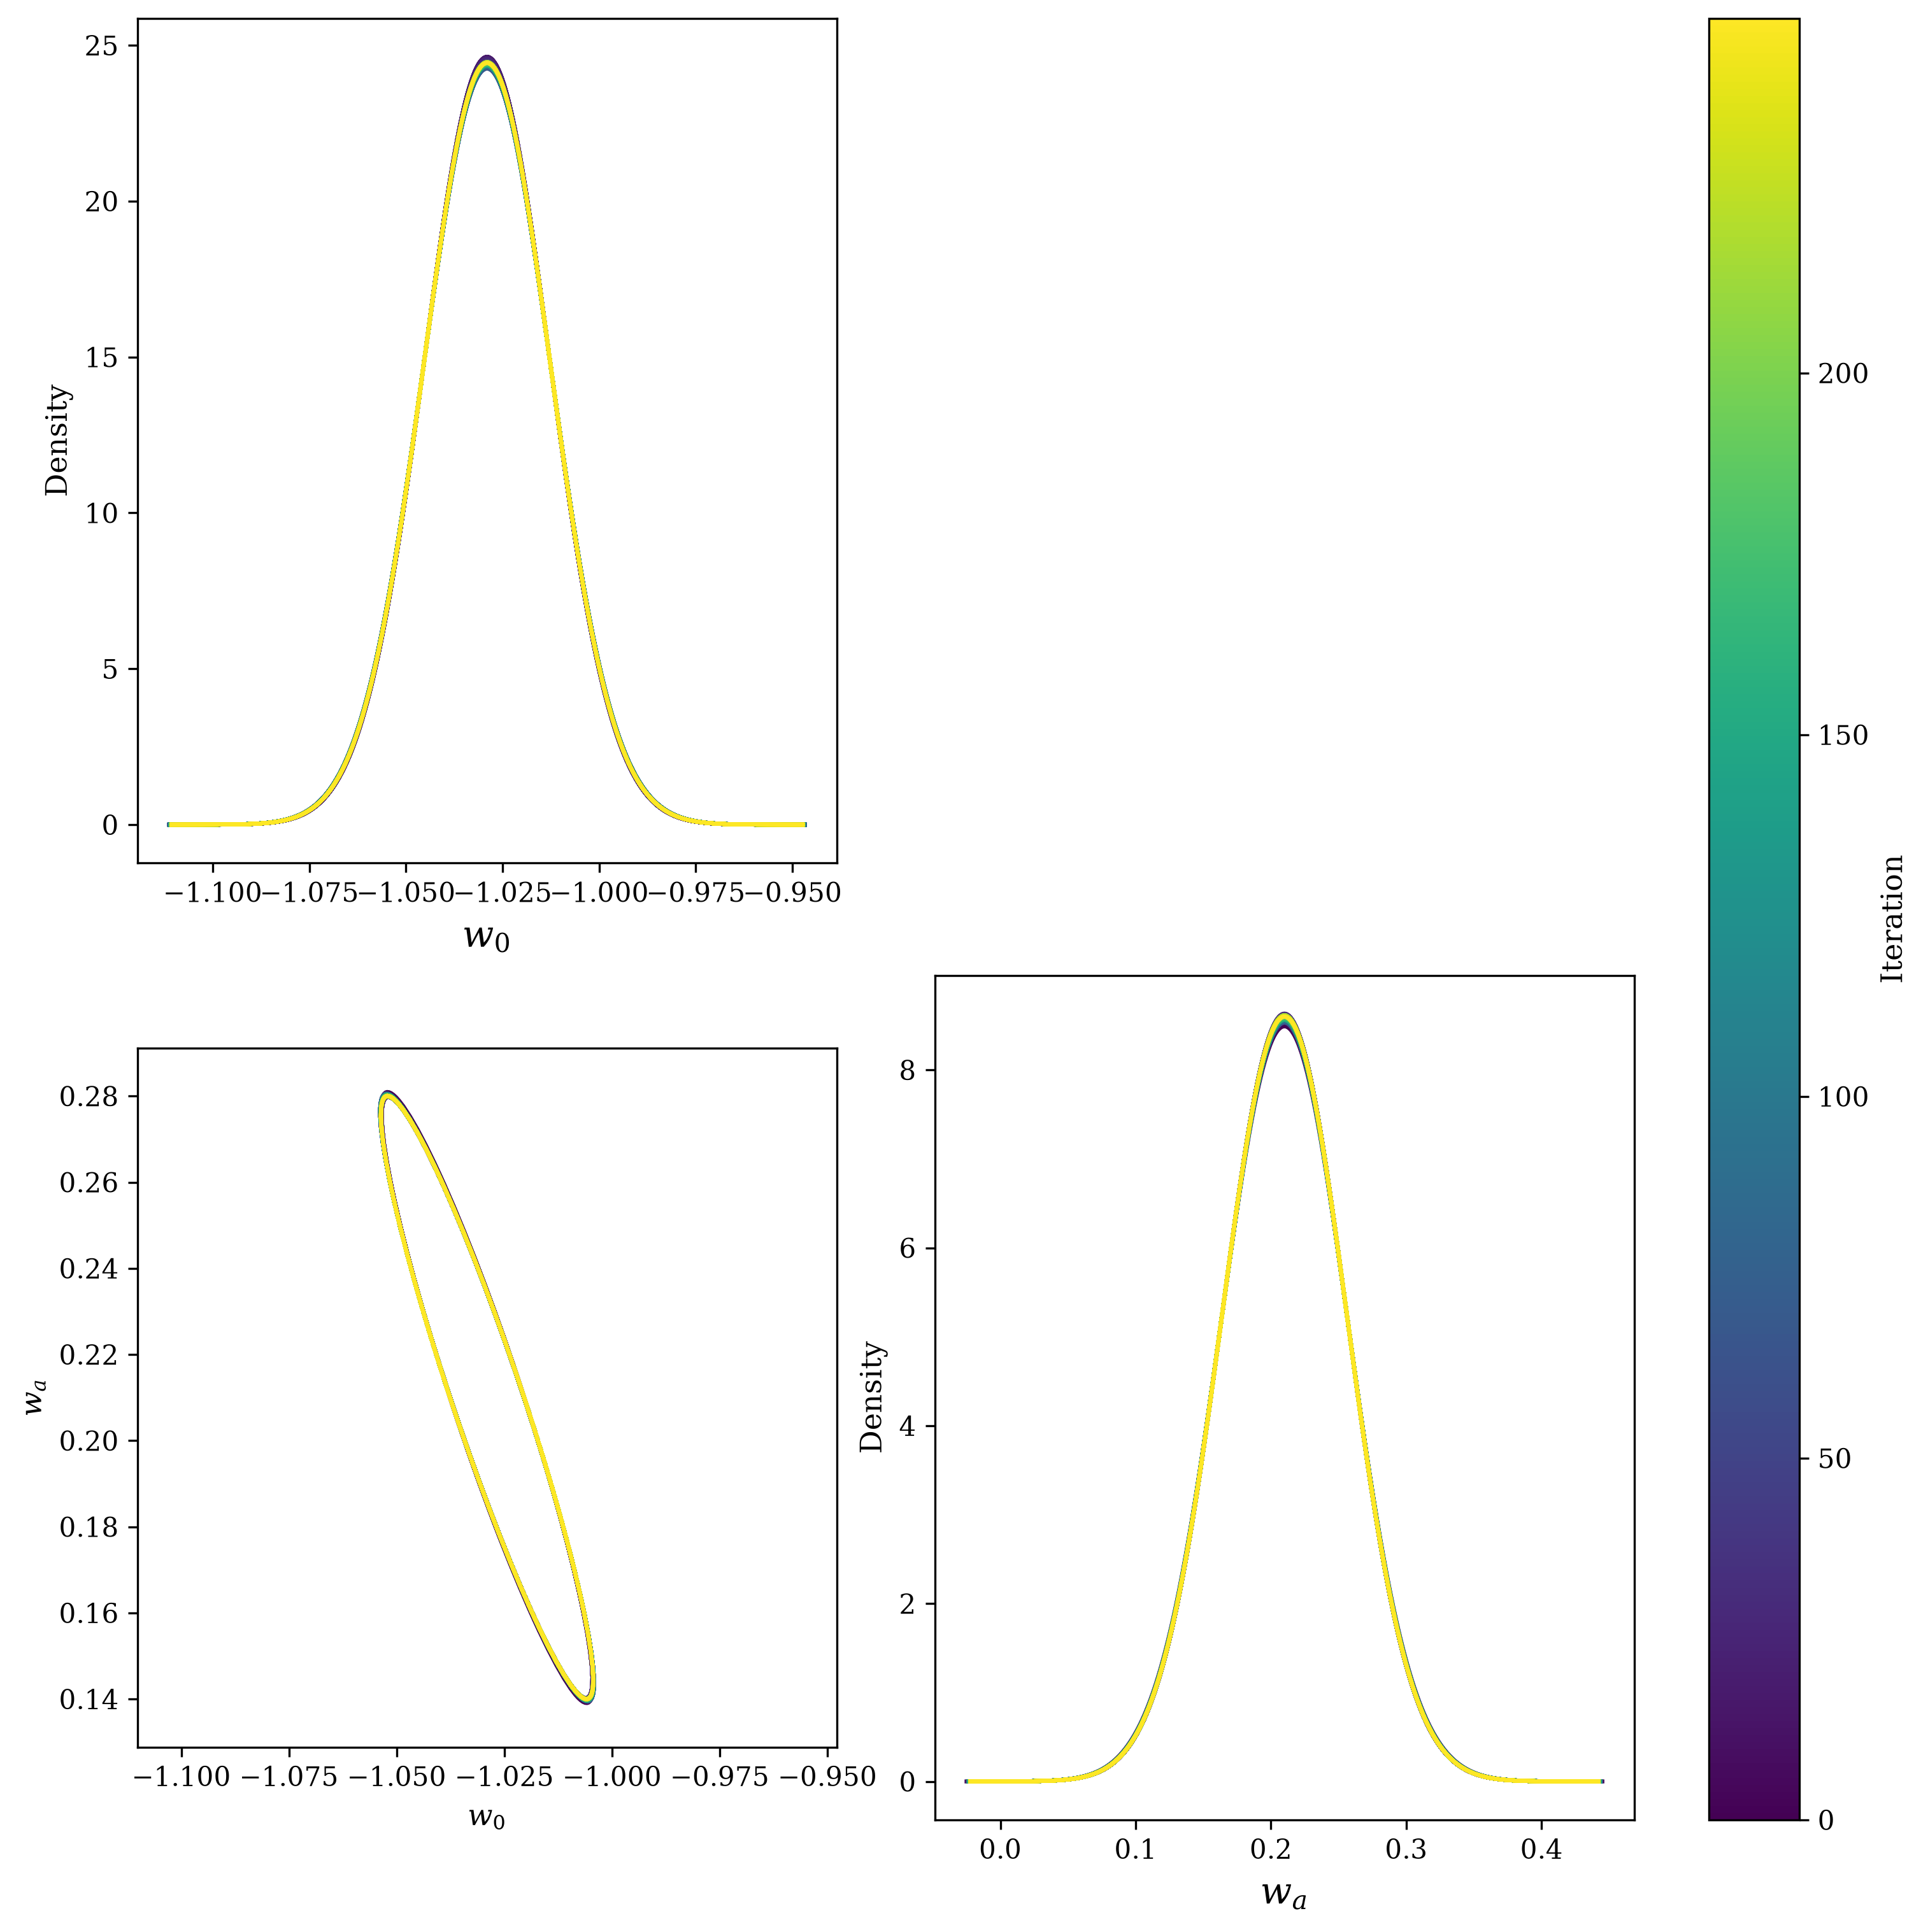

In [64]:
param_names = ['w0', 'wa']
param_labels = [r'$w_0$', r'$w_a$']
param_to_plot = ['w0', 'wa']
fiducial_param = [w0_fCPL, wa_fCPL]

N = len(track_FF)

cmap = cm.viridis
norm = plt.Normalize(vmin=0, vmax=N - 1)
clrs = cmap(norm(np.arange(N)))

fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names,
    param_to_plot,
    param_labels,
    figsize=10
)

for i, fisher_matrix in enumerate(track_FF):

    fma.add_fisher_to_plot(
        fisher_matrix,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color=clrs[i],
        filled=False,
        param_labels=param_labels
    )

# ---------------------------------------------------------
# Colorbar
# ---------------------------------------------------------

sm = plt.cm.ScalarMappable(
    norm=norm,
    cmap=cmap
)
sm.set_array([])

fig.colorbar(
    sm,
    ax=[axs_1d[0], axs_1d[1]],
    label='Iteration',
    pad=0.05
)

# plt.savefig(
#     'figures/track_ellipses_roman_100',
#     bbox_inches='tight'
# )

plt.show()


In [65]:
FF_fake


Array([[ 22434.29927138,   6336.99871915,   1226.7012674 ,
        -18559.18744971],
       [  6336.99871915,   1956.9682569 ,    354.03262251,
         -5603.38007378],
       [  1226.7012674 ,    354.03262251,     69.40323175,
          -941.19050624],
       [-18559.18744971,  -5603.38007378,   -941.19050624,
         24005.25591522]], dtype=float64)

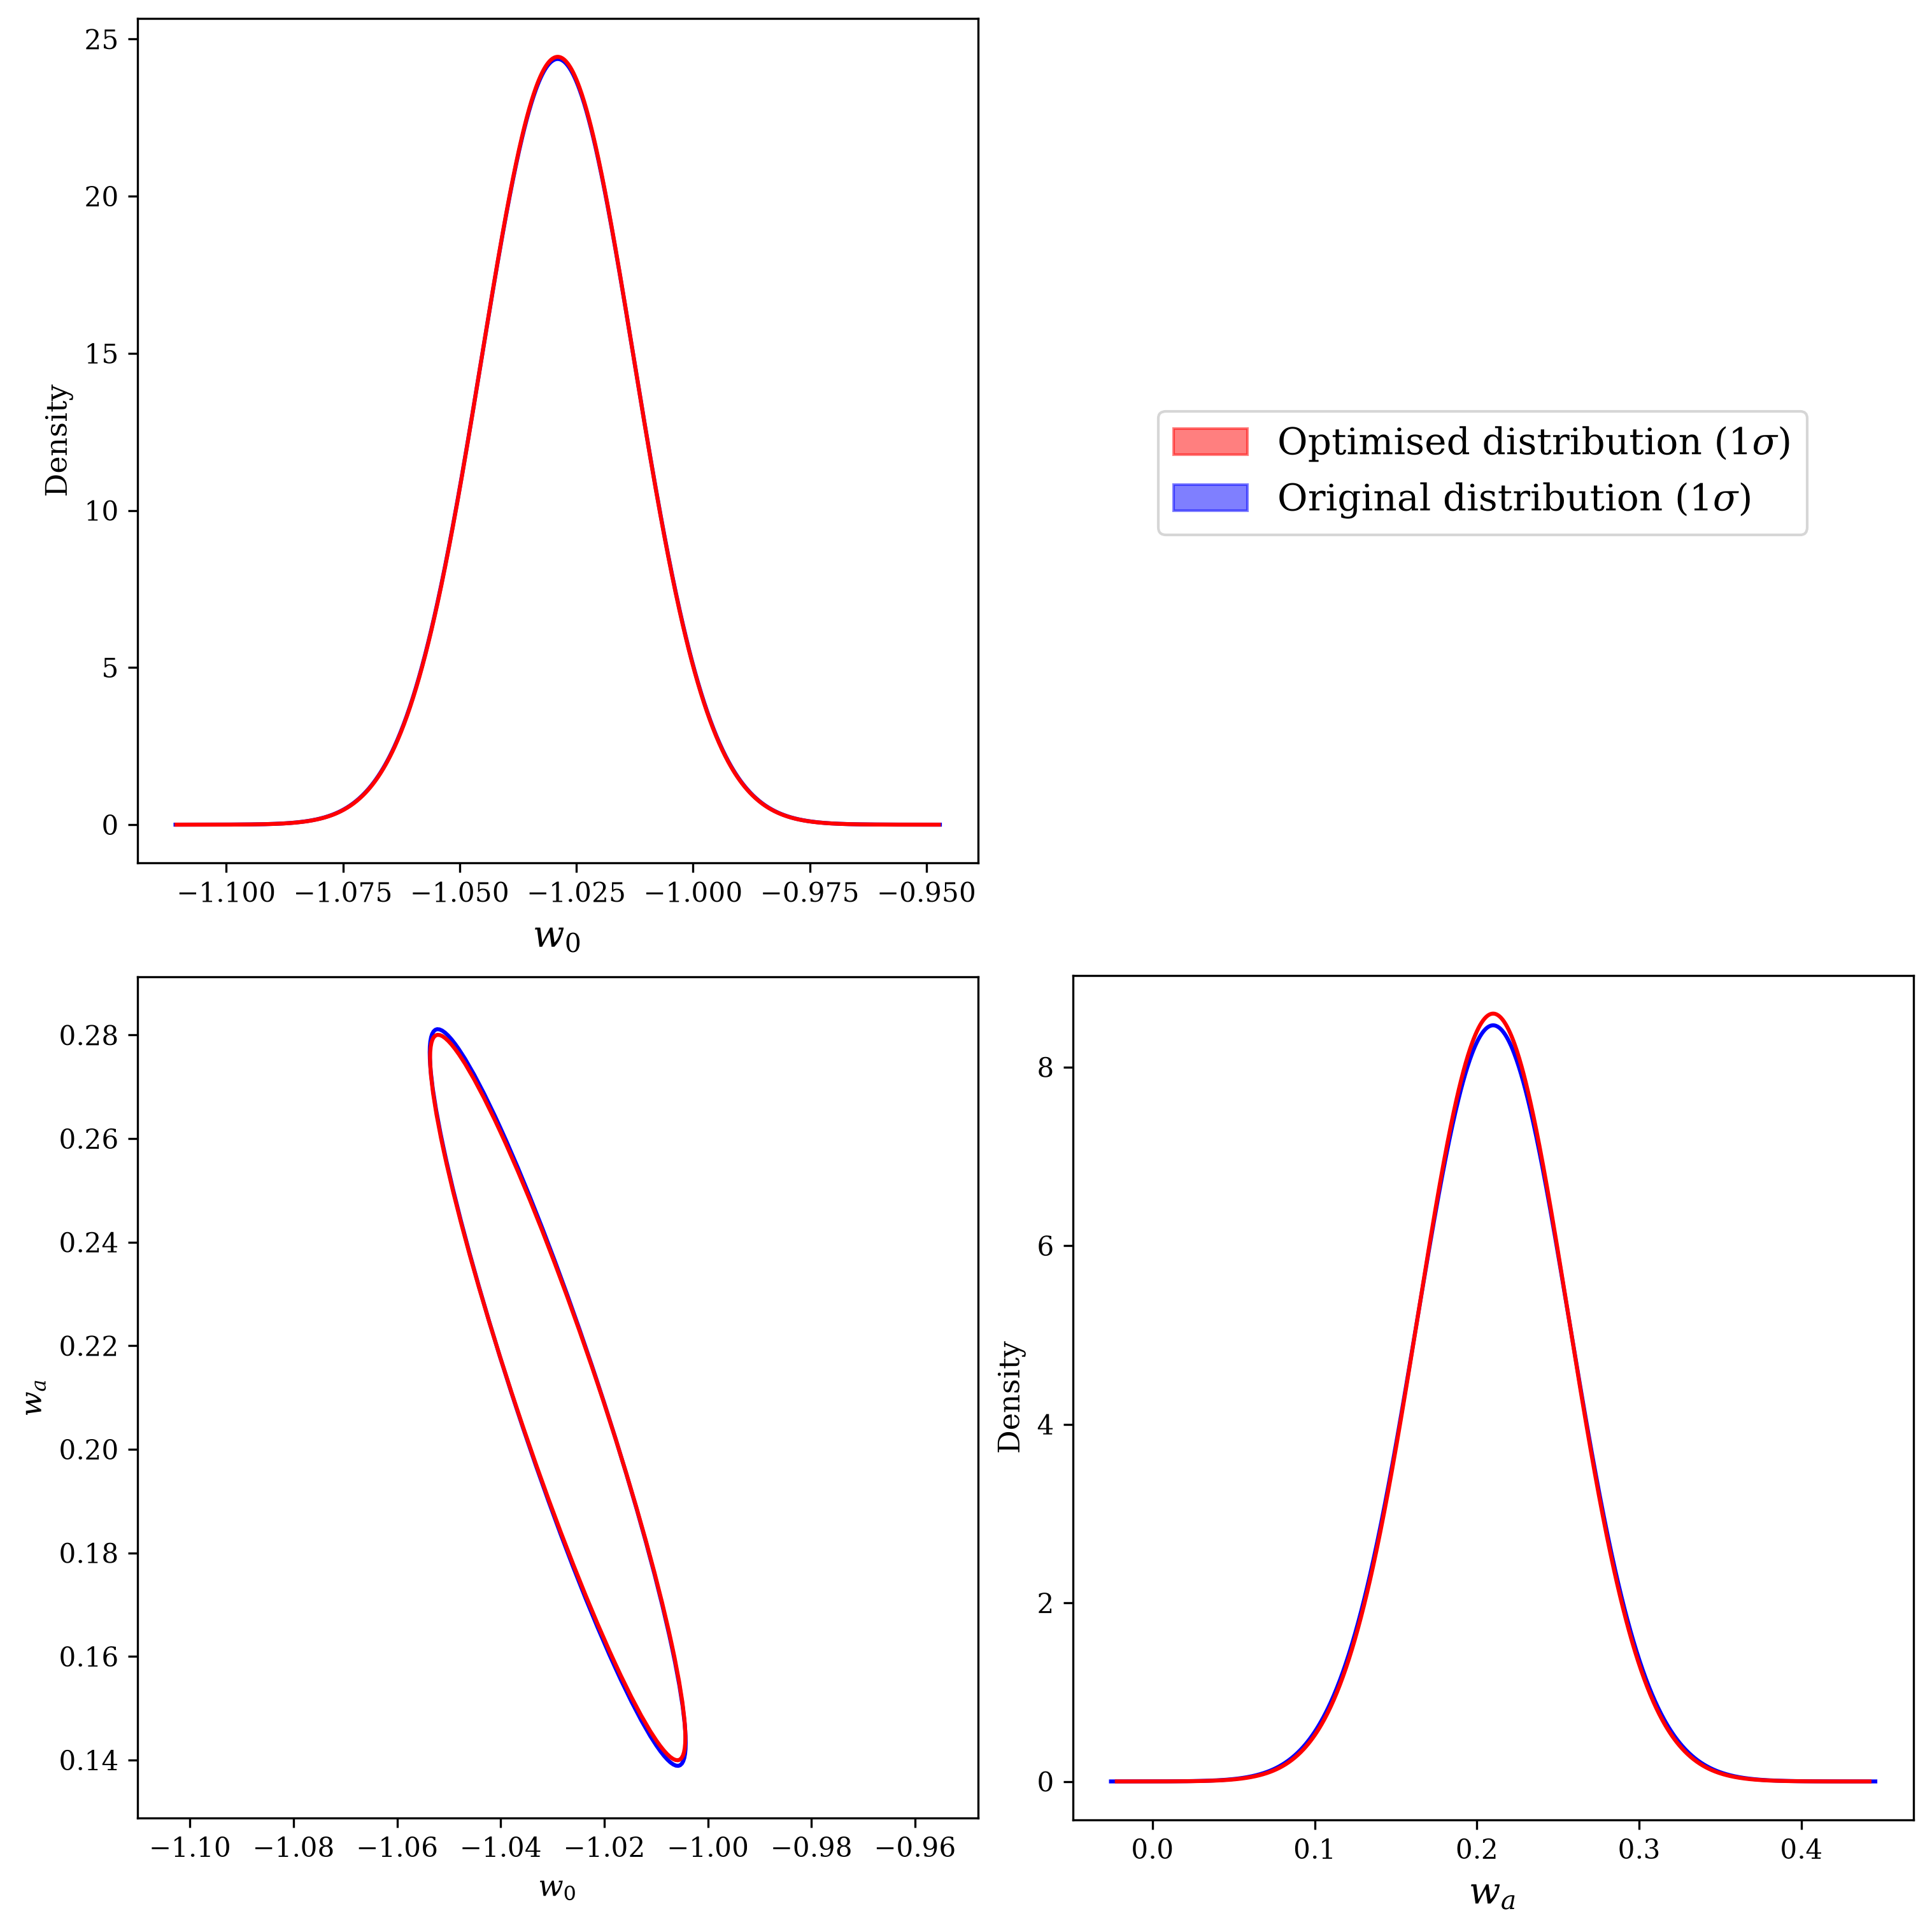

In [66]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        track_FF[-1],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        param_labels=param_labels
    )

# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='red', edgecolor='red', alpha=0.5, label=r'Optimised distribution (1$\sigma$)'),
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    #Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'Iteration 5000(1$\sigma$)')
    ]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
#plt.savefig('figures/ellispes_comparison_roman_25000')
# Show the final overlaid plot
plt.show()

In [67]:
# dFOM_pbin = np.zeros_like(z_roman, dtype=float)

# for ii in range(len(dist_roman)):

#     dist_perturbed = np.array(dist_roman, copy=True)
#     dist_perturbed[ii] += 1.0

#     Covi = opt_jax.build_covariance(
#         dist_perturbed,
#         dist_roman,
#         Cov_roman_stat,
#         Cov_roman_sys,
#     )

#     Cov_invi = np.linalg.solve(
#         np.asarray(Covi),
#         np.eye(len(dist_roman)),
#     )

#     FFi = opt_jax.fisher_matrix_observable(
#         fiducial_cosmo,
#         Cov_invi,
#         z_roman,
#         H0,
#     )

#     CCi = opt_jax.marginalize_fisher_matrix(
#         FFi,
#         ('w0', 'wa'),
#         ['Om0', 'w0', 'wa', 'Mb'],
#     )

#     AAi = opt_jax.ellipse_parameters(
#         CCi,
#         0.32,
#     )[3]

#     FOMi = 1.0 / AAi

#     dFOM_pbin[ii] = (FOMi - FOM) / tt[ii]

In [68]:
# for i, cc in enumerate(track_Cov):
#     print(fma.is_positive_definite(cc))
#     if not fma.is_positive_definite(cc):
#         print(f"First False at index {i}")
#         break
# else:
#     print("All matrices are positive definite")

In [69]:
# track_Cov.shape

In [70]:
# np.diag(Cov_roman)

In [71]:
# cc_sys = Cov_roman-np.diag(np.diag(Cov_roman))
# vmin=np.min(cc_sys)
# vmax=np.max(cc_sys)
# norm = colors.Normalize(vmin=-max(np.abs(vmin),np.abs(vmax)), 
#                         vmax=max(np.abs(vmin),np.abs(vmax)))

# plt.imshow(cc_sys,norm=norm)

# plt.colorbar()

In [72]:
# Cov_roman1 = track_Cov[0]
# Cov_roman2 = track_Cov[1]

# norm = colors.Normalize(vmin=np.min(Cov_roman), vmax=np.max(Cov_roman))

# plt.imshow(Cov_roman1,norm=norm)
# plt.colorbar()

# SNIa Volumetric rate

In [73]:
Tobs_roman_yr = (obs_time_roman/(3600*24*365.25))
Tobs_roman_yr

np.float64(2.5316601204985347)

In [74]:
# Cosmology
cosmo = ac.FlatLambdaCDM(H0=70, Om0=0.3)

# Example volumetric SNIa rate
# yr^-1 Mpc^-3
def R_Ia(z):
    return 2.4e-5 * (1 + z)**1.55

# Detection efficiency
def efficiency(z):
    return 1.0

# Survey duration in observer frame
Tobs = Tobs_roman_yr +0.1 # years 
    # on l'augmente un peu pour que ça passe avec dist_roman

# Tier areas
areas = {
    "deep": 6.47,   # deg^2
    "wide": 18.27
}
NIa_deep = np.zeros_like(z_roman)
NIa_wide = np.zeros_like(z_roman)

for tier, area_deg2 in areas.items():

    omega = area_deg2 * (np.pi / 180.)**2

    for i in range(len(z_edges) - 1):
        z1 = z_edges[i]
        z2 = z_edges[i + 1]
        zmid = 0.5 * (z1 + z2)

        # Full-sky comoving volumes
        V1 = cosmo.comoving_volume(z1).value
        V2 = cosmo.comoving_volume(z2).value

        # Shell volume for survey footprint
        Vshell = (omega / (4*np.pi)) * (V2 - V1)

        # Expected number
        N = (
            R_Ia(zmid)
            * Vshell
            * (Tobs / (1 + zmid))
            * efficiency(zmid)
        )

        if tier == "deep":
            NIa_deep[i] = N
        elif tier == "wide":
            NIa_wide[i] = N        

In [75]:
NIa_tot = NIa_deep + NIa_wide
NIa_tot.round(0)

array([  11.,   28.,   53.,   85.,  123.,  166.,  214.,  265.,  319.,
        376.,  433.,  492.,  551.,  611.,  670.,  728.,  786.,  843.,
        898.,  952., 1004., 1055., 1105., 1152., 1198., 1242., 1285.,
       1326., 1365., 1403., 1439., 1473., 1506., 1538., 1568., 1597.,
       1624., 1650., 1675., 1699., 1721., 1743., 1763., 1782., 1801.,
       1818., 1834., 1850., 1865., 1879., 1892., 1905., 1917., 1928.,
       1938., 1948., 1958., 1966., 1974.])

In [76]:
np.less_equal(dist_roman_without_lsst, NIa_tot)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

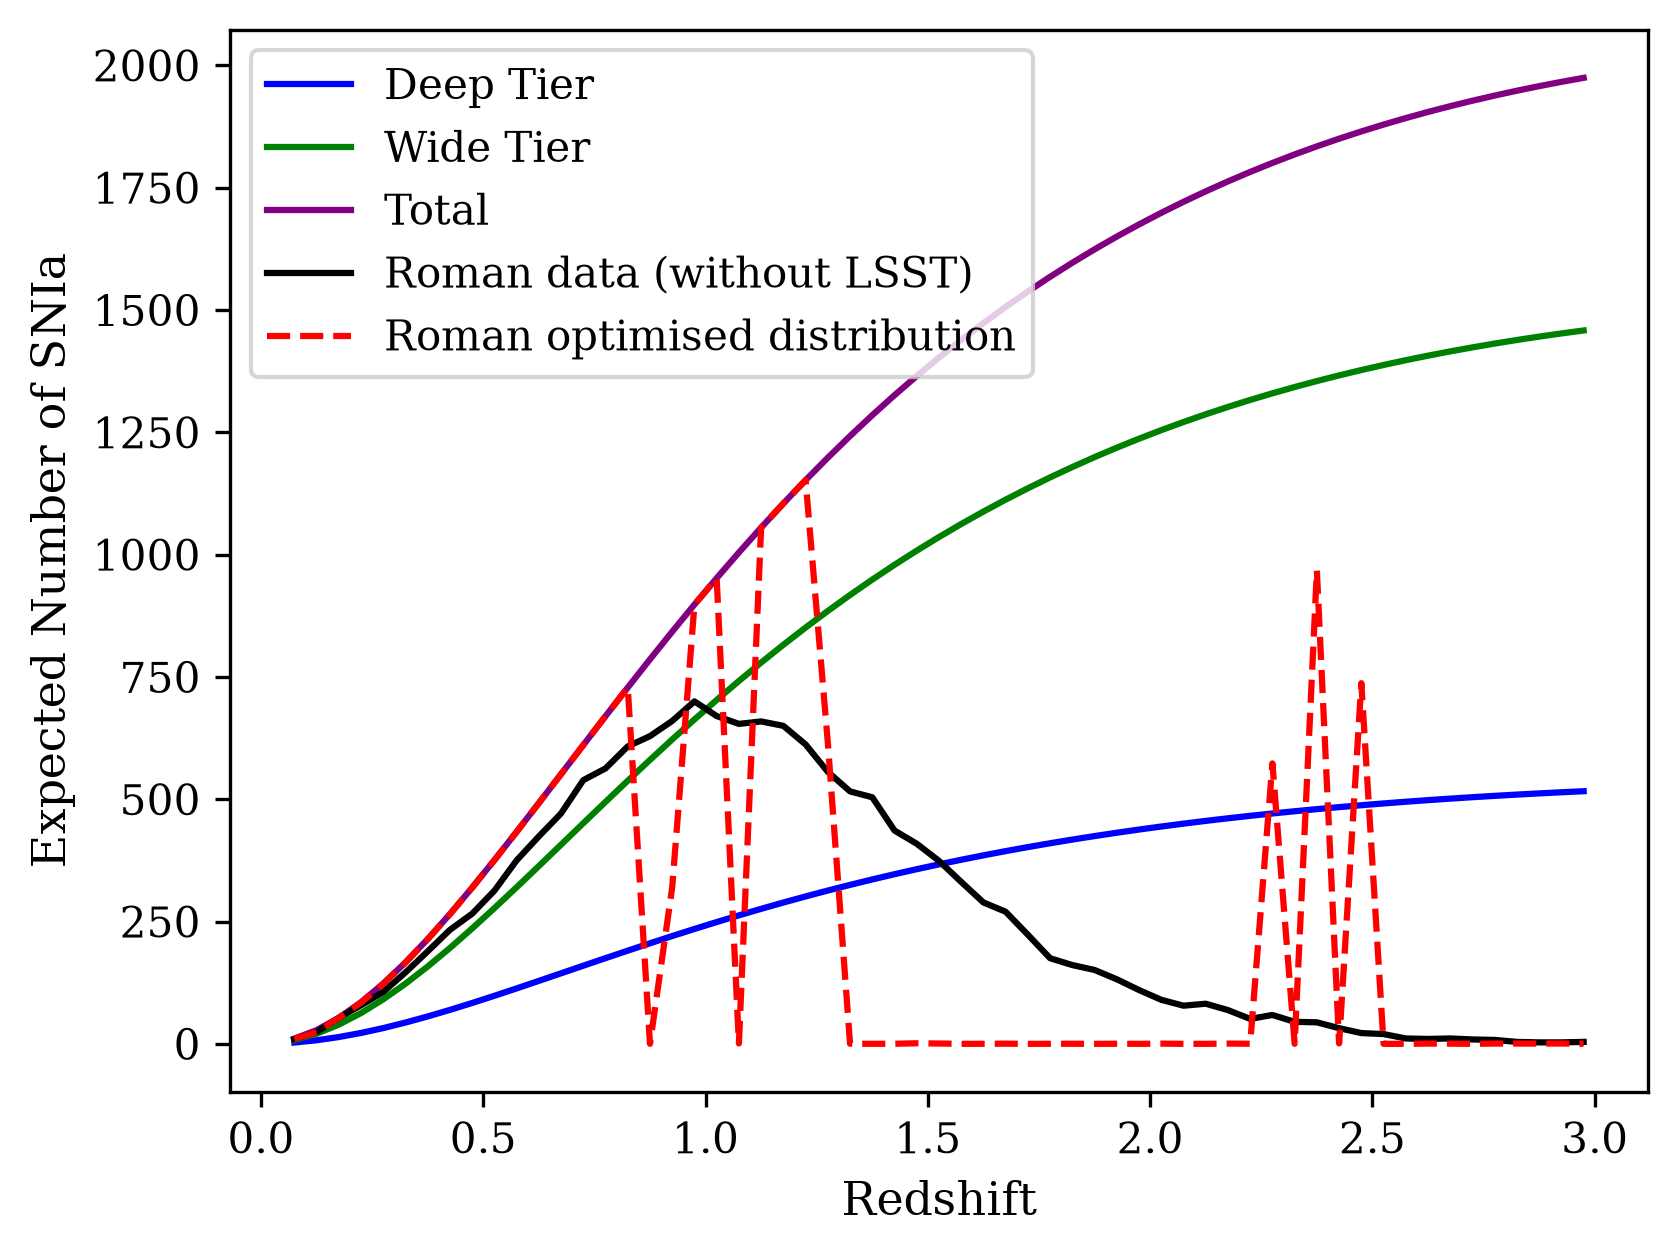

In [77]:
plt.plot(z_roman, NIa_deep, label="Deep Tier", color="blue")
plt.plot(z_roman, NIa_wide, label="Wide Tier", color="green")
plt.plot(z_roman, NIa_tot, label="Total", color="purple")
plt.plot(z_roman, dist_roman_without_lsst, label='Roman data (without LSST)', color='black')
plt.plot(z_roman, optimized_dist-lsst_SNIa, label='Roman optimised distribution', color='red', ls='--')
plt.xlabel("Redshift")
plt.ylabel("Expected Number of SNIa")
plt.legend()
plt.show()

In [78]:
# np.savez('SNIa_count.npz',
#          z_roman=z_roman,
#          NIa_wide=NIa_wide,
#          NIa_deep=NIa_deep,
#          NIa_tot=NIa_tot
#          )

In [79]:
# # plot survey volume as function of redshift for each tier
# plt.plot(z_roman, areas["deep"] * cosmo.comoving_volume(z_roman).value / (4*np.pi), label="Deep Tier", color="blue")
# plt.plot(z_roman, areas["wide"] * cosmo.comoving_volume(z_roman).value / (4*np.pi), label="Wide Tier", color="red")
# plt.xlabel("Redshift")
# plt.ylabel("Survey Volume (steradians)")
# plt.legend()
# plt.show()